In [11]:
# base figure for CCN extended abstract & BNC poster

# import umap
import tqdm as notebook_tqdm
from base_entity import Entity, Material, Coord, Property
from base_gameLogic import Action as A, Tile, Boundary, GameEngine, GameOutcome
from base_rule import Token
from recorder import get_data_manager, Trans, State, StateKey, Gridmap, TransKey
from plan_hierachy import PlanBuilder, Plan, PlanKey

from util import decoding, encoding, save_df_with_schema, load_df_with_schema, ALL_MAP
from work_plan_structure import get_plan_structure, get_post_grid
import pandas as pd
from trans_analyzer import PushChain, TransAnalyzer
from collections import defaultdict
from time import time
from state_storage import get_data_manager



In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.patches import Ellipse, FancyArrowPatch
import numpy as np
from scipy import stats
import hashlib

from state_graphic import *
from mdpframework import Environment, MapManager
import seaborn as sns
from recorder import get_data_manager, Trans, State, StateKey, Gridmap, TransKey, Hybrid
from util import decoding, encoding, save_df_with_schema, load_df_with_schema



In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from util import decoding
from trans_analyzer import PushChain
from recorder import Gridmap, State
from mdpframework import Environment
from state_storage import get_data_manager
from scipy.stats import entropy
def relative_entropy(counts):
    return entropy(counts) / np.log(counts.sum()) if counts.sum() > 1 else np.nan
def calculate_gini(array):
    array, n, index = np.sort(array), array.shape[0], np.arange(1, array.shape[0] + 1)
    return (np.sum((2 * index - n - 1) * array)) / (n * np.sum(array))

# 0 HMM Results

! 目前纯HMM相关结果已经转移到model_hmm_demo.ipynb和model_hmm.py部分

## Fitted Parameters

In [13]:
hmm_p = pd.read_csv('../data/all_subject_hmm_param_with_pi.csv')
all_maps = hmm_p['Map'].unique()
common_maps = ['intro', 'tutorial', 'base', 'target']
hmm_p4 = hmm_p[hmm_p['Map'].isin(common_maps)].copy()
nodes = ['Exe', 'Pre', 'Plan', 'Post']
state_mapping = {'0': 'Exe', '1': 'Pre', '2': 'Post', '3': 'Plan'}
# def rename_cols(col):
#     for old, new in state_mapping.items():
#         col = col.replace(old, new)
#     return col
# for col in hmm_p.columns:
#     new_col = rename_cols(col)
#     if new_col != col:
#         hmm_p.rename(columns={col: new_col}, inplace=True)

In [ ]:
def get_transition_matrix(data, level = None):
    if level is not None:
        data = data[data.Map == level]
    return data[tran_p].mean().values.reshape(4, 4)

def get_subject_pi(row):
    matrix = row[tran_p].values.reshape(4, 4)
    return get_station_pi(matrix)

# for i, j in hmm_p.iterrows():
#     sub_pi = get_subject_pi(j)
#     if abs(sum(sub_pi) - 1) > 1e-6:
#         print(f"Warning: Subject {j[['Map', 'Subject']]} has non-stationary distribution: {sub_pi}")
#     for node, pi in zip(nodes, sub_pi):
#         hmm_p.loc[i, f"pi_{node}"] = pi
        
def get_station_pi(matrix):
    pi = np.array([0., 0., 0., 1.])
    for i in range(10000):
        pi_new = pi @ matrix
        if np.linalg.norm(pi_new - pi) < 1e-10:
            break
        pi = pi_new
    return pi

In [8]:

mu_p = [c for c in hmm_p.columns if c.startswith('mu_')]
sigma_p = [c for c in hmm_p.columns if c.startswith('sigma_')]
tran_p = [c for c in hmm_p.columns if c.startswith('A_')]
pi_p = [c for c in hmm_p.columns if c.startswith('pi_')]
hmm_p[pi_p].mean() # 0 Execution, 1 Pre-, 2 Post, 3 Planning

pi_Exe     0.262067
pi_Pre     0.250410
pi_Plan    0.319816
pi_Post    0.167708
dtype: float64

In [249]:
def ellipse_boundard(center, width, height, angle):
    cx, cy, a, b = center[0], center[1], width/2, height/2
    t = np.sqrt(a**2 * np.cos(angle)**2 + b**2 * np.sin(angle)**2)
    return (cx + t * np.cos(angle), cy + t * np.sin(angle))

def get_arrow(source, target, width, height):
    dx, dy = target[0] - source[0], target[1] - source[1]
    angle = np.arctan2(dy, dx)
    start_p = ellipse_boundard(source, width, height, angle)
    end_p = ellipse_boundard(target, width, height, angle + np.pi)
    return start_p, end_p

def get_circular(source, angle, diff, width, height):
    start_p = ellipse_boundard(source, width, height, angle - np.pi/6 * diff)
    end_p = ellipse_boundard(source, width, height, angle + np.pi/6 * diff)
    return start_p, end_p

def draw_arrow(start_p, end_p, rad, color, width):
    return FancyArrowPatch(start_p, end_p,
                           connectionstyle=f"arc3,rad={rad}",
                            arrowstyle='->',
                            mutation_scale=20,
                            color=color,
                            linewidth=width)

matrix = get_transition_matrix(hmm_p)

def draw_hmm_structure(matrix = matrix, e_width = 0.8, e_height = 0.6, saving = None):
    # 定义节点位置和颜色
    Exe, Pre, Plan, Post = "Routine\nExecution", "Pre-Deliberative\nPreparation", "Deliberative\nPlanning", "Post-Deliberative\nStablization"
    nodes = [Exe, Pre, Post, Plan]
    pos = {Exe: (1, 0), Pre: (0, 1), Post: (2, 1),  Plan: (1, 2)}
    colors = {Exe: '#c8b9e0', Pre: '#95d1b0', Plan: '#f0e4a0', Post: '#95d1b0'}
    station_distribution = get_station_pi(matrix)
    station_pi = {node: station_distribution[i] for i, node in enumerate(nodes)}
    

    G = nx.DiGraph()
    [G.add_node(node, pos=p) for node, p in pos.items()]
    edges_with_weights = [(nodes[i], nodes[j], matrix[i, j]) for i in range(4) for j in range(4) if matrix[i, j] > 0.01]
    [G.add_edge(s, t, weight=w) for s, t, w in edges_with_weights]

    plt.figure(figsize=(12, 9))
    ax = plt.gca()
    
    # 绘制椭圆节点
    for node, (x, y) in pos.items():
        ellipse = Ellipse((x, y), width=e_width, height=e_height, facecolor=colors[node], edgecolor='black', linewidth=2)
        ax.add_patch(ellipse)
        ax.text(x, y, node, ha='center', va='center',fontsize=17, fontweight='bold', wrap=True)
    
    # 只为真实存在的边绘制权重标签
    for source, target, data in G.edges(data=True):
        weight = data['weight'] 
        edge_color = colors[source]  # 边的颜色与出发节点一致
        line_width = weight * 25  # 调整线宽比例，让差异更明显
        
        if source == target:  # 自环 - 手动绘制带偏移的自环            
            # 根据节点位置确定自环的方向和偏移 - 仿照Exe的模式
            if source == Exe:  # bottom - 向下的自环
                start_point, end_point = get_circular(pos[source], 0, 1, e_width, e_height)
                label_offset = (0.65, 0)
            elif source == Pre:  # left - 向左的自环，仿照Exe的模式
                start_point, end_point = get_circular(pos[source], -np.pi/2, 1, e_width, e_height)
                label_offset = (-0.2, -0.5)
            elif source == Plan:  # top - 向上的自环，仿照Exe的模式
                start_point, end_point = get_circular(pos[source], np.pi, 1, e_width, e_height)
                label_offset = (-0.65, 0)
            elif source == Post:  # right - 向右的自环，仿照Exe的模式
                start_point, end_point = get_circular(pos[source], np.pi/2, 1, e_width, e_height)
                label_offset = (0.2, 0.5)
            
            arrow = FancyArrowPatch(start_point, end_point,
                                  connectionstyle="arc3,rad=1",  # 增大弧度让自环更圆
                                  arrowstyle='->', 
                                  mutation_scale=20,  # 增大箭头
                                  color=edge_color, 
                                  linewidth=line_width)  # 增加最小线宽
            ax.add_patch(arrow)
            
            # # 标注自环权重
            plt.text(pos[source][0] + label_offset[0], pos[source][1] + label_offset[1], 
                    f'{weight*100:.1f}%', fontsize=14, fontweight='bold',
                    bbox=dict(boxstyle="round,pad=0.3", facecolor=edge_color, alpha=0.5, edgecolor=edge_color),
                    ha='center', va='center')
                    
        else:  # 普通边
            start_point, end_point = get_arrow(pos[source], pos[target], e_width, e_height)
            arrow = FancyArrowPatch(start_point, end_point,
                                  connectionstyle='arc3, rad=0.2',
                                  arrowstyle='->', 
                                  mutation_scale=20, 
                                  color=edge_color, 
                                  linewidth=max(3, line_width))
            ax.add_patch(arrow)
            
            # 计算边中点位置标注权重
            source_pos = pos[source]
            target_pos = pos[target]
            mid_x = (source_pos[0] + target_pos[0]) / 2
            mid_y = (source_pos[1] + target_pos[1]) / 2
            
            # 为反向边调整偏移避免重叠
            offset = 0.1
            # 检查是否有反向边
            reverse_edge_exists = G.has_edge(target, source)
            if reverse_edge_exists and (source, target) < (target, source):
                # 这是"较小"的边，偏移到一侧
                offset = -offset
         
            plt.text(mid_x + offset, mid_y + offset, 
                    f'{weight*100:.1f}%', fontsize=14, fontweight='bold',
                    bbox=dict(boxstyle="round,pad=0.2", facecolor=edge_color, alpha=0.5, edgecolor=edge_color),
                    ha='center', va='center')

    # plt.title("4-State HMM Transition Structure with Weights (%)", pad=30, fontsize=14, fontweight='bold')
    
    # 调整显示范围，为自环留出更多空间
    plt.xlim(-0.5, 2.5)
    plt.ylim(-0.3, 2.3)
    # plt.title(saving)
    plt.axis('off')
    
    # 保存为PDF
    if saving is not None:
        
        plt.savefig(f'CCNFig/{saving}.pdf', format='pdf', dpi=300, transparent=True)
        print(f"HMM结构图已保存为 CCNFig/{saving}.pdf")
    plt.show()

HMM结构图已保存为 CCNFig/HMMTransition.pdf


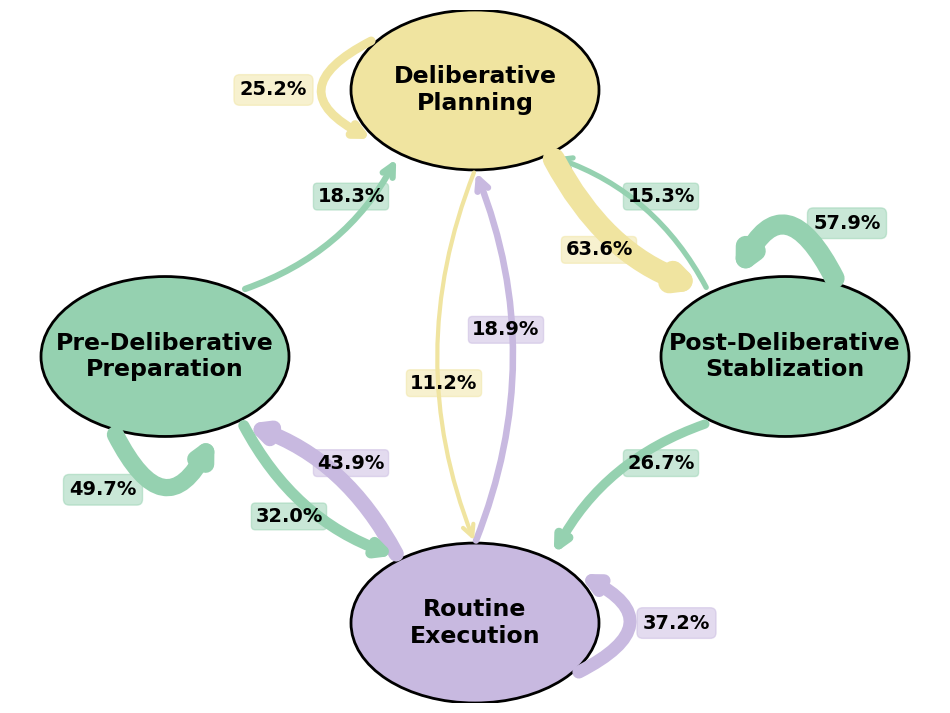

In [250]:
draw_hmm_structure(get_transition_matrix(hmm_p), saving='HMMTransition')

In [140]:
# for map in all_maps:
#     print(f"Drawing HMM structure for map: {map}")
#     matrix = get_transition_matrix(hmm_p, level=map)
#     print(f"Stationary distribution for {map}: {get_station_pi(matrix).round(2)}")
#     draw_hmm_structure(matrix, saving=f"HMM_trans_{map}")

In [34]:
# 困难与简单关卡的比较
Level = {'intro': 'Small_Simple', 'tutorial': 'Small_Simple', 'base': 'Large_Complex', 'target': 'Large_Complex', 
         'break': 'Large_Simple', 'maze': 'Large_Simple', 'make': 'Large_Simple', 'helper': 'Large_Simple'}
hmm_p['Level'] = hmm_p['Map'].map(Level)
hmm_p.groupby('Level')[mu_p].mean()

,mu_Exe,mu_Pre,mu_Post,mu_Plan
Level,,,,
Large_Complex,0.030836,0.388242,0.462338,1.517856
Large_Simple,0.034959,0.408256,0.460694,1.511108
Small_Simple,0.106296,0.765070,0.809401,2.255722


In [36]:
hmm_p.groupby('Level')[pi_p].mean()  # 警告：平稳分布的数据不可靠

,pi_Exe,pi_Pre,pi_Plan,pi_Post
Level,,,,
Large_Complex,0.201994,0.173961,0.415876,0.208169
Large_Simple,0.208123,0.178819,0.398089,0.214969
Small_Simple,0.349111,0.362655,0.184618,0.103616


## Fitted data

In [3]:
env = Environment(Gridmap)
env.init_experience('../data/full_1119.csv')
df = env.em.rebuild_total_df().sort_values(['Uid', 'Count_Global'])

ALL_MAP = ['intro', 'tutorial', 'base', 'target', 'maze', 'make', 'break', 'helper']
ALL_LEVEL = ['Unit', 'Chunk', 'Seq', 'Subgoal', 'Full']

colors = ['#f0e4a0', '#95d1b0', '#95d1b0', '#c8b9e0']  # Plan, Post, Pre, Exe
deeper_colors = ['#d4c466', '#6bb387', '#6bb387', '#a896c7']  # 更深的协调颜色
label_order = ['Plan\nPD=2', 'Post\nPD=1', 'Pre\nPD=1', 'Exe\nPD=0']




In [261]:
def calculate_stats(data): return data.mean(), data.std()

def plot_violin_with_stats(plot_df, y, x, label_order, colors, deeper_colors, ax):

    sns.violinplot(data=plot_df, y=y, x=x, order=label_order,  palette=colors, 
                   alpha=0.6, inner=None, cut=0, bw_adjust=0.8, gridsize=200, ax=ax)

    color_map = {label_order[i]: deeper_colors[i] for i in range(len(label_order))}
    for i, label in enumerate(label_order):
        subset = plot_df[plot_df[y] == label][x]
        if len(subset) > 1:
            mean, std = calculate_stats(subset)
            color = color_map[label]

        ax.scatter(mean, i, s=80, color=color, zorder=10, marker='D', edgecolor='white', linewidth=2)
        std_low, std_high = mean - std, mean + std
        ax.plot([std_low, std_high], [i, i], color=color, linewidth=4, zorder=10, alpha=0.9)
        ax.scatter([std_low, std_high], [i, i], s=60, color=color, zorder=10, marker='|', linewidth=3)


C:\Users\asus\AppData\Local\Temp\ipykernel_33712\2307469811.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, y=y, x=x, order=label_order,  palette=colors,


Violin plot版本的HMM RT分布图已保存为 CCNFig/HMMmeanRT_violin.pdf


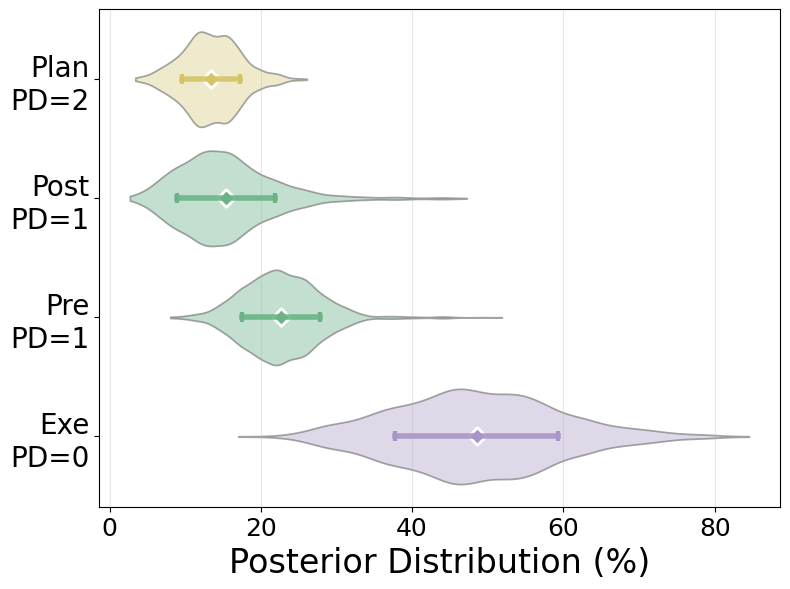

In [289]:
plot_df = (df.groupby(['Uid'])['pred_maximum'].value_counts(normalize=True)*100).reset_index()
plot_df['pred_label'] = plot_df['pred_maximum'].map(pred_labels)
# df[df.Map == 'intro'].groupby(['Uid'])[['pred_state_0', 'pred_state_1', 'pred_state_2', 'pred_state_3']].mean().mean()

fig, ax = plt.subplots(figsize=(8, 6))
plot_violin_with_stats(plot_df, y='pred_label', x='proportion', label_order=label_order, colors=colors, deeper_colors=deeper_colors, ax=plt.gca())
plt.ylabel('', fontsize=18)
plt.xlabel('Posterior Distribution (%)', fontsize=24)
plt.xticks(fontsize=18)
plt.yticks(fontsize=20)
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
# 保存为PDF
plt.savefig('CCNFig/HMMmeanDist_violin.pdf', format='pdf', dpi=300, bbox_inches='tight', transparent=True)
print("Violin plot版本的HMM RT分布图已保存为 CCNFig/HMMmeanRT_violin.pdf")
plt.show()


C:\Users\asus\AppData\Local\Temp\ipykernel_33712\2307469811.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, y=y, x=x, order=label_order,  palette=colors,


Violin plot版本的HMM RT分布图已保存为 CCNFig/HMMmeanRT_violin.pdf


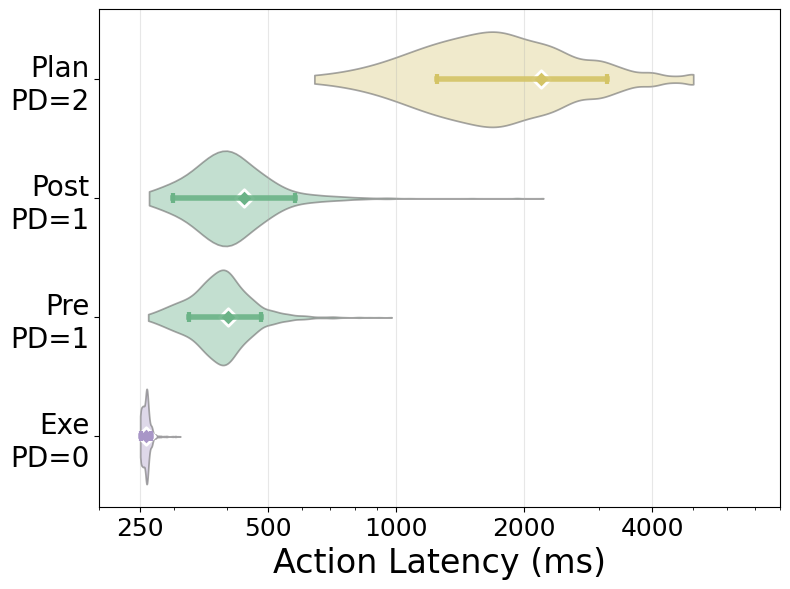

In [264]:
sub_df = df.copy()
data = sub_df.groupby(['pred_maximum', 'Uid'])['Before'].mean()
plot_df = data.reset_index()
pred_labels = {0: 'Exe\nPD=0', 1: 'Pre\nPD=1', 2: 'Post\nPD=1', 3: 'Plan\nPD=2'}
plot_df['Before'] = plot_df['Before'].clip(0, 5000)
plot_df['pred_label'] = plot_df['pred_maximum'].map(pred_labels)

fig, ax = plt.subplots(figsize=(8, 6))
plot_violin_with_stats(plot_df, 'pred_label', 'Before', label_order, colors, deeper_colors, ax=ax)

# 美化图表
plt.xscale('log')
plt.ylabel('', fontsize=18)
plt.xlabel('Action Latency (ms)', fontsize=24)
plt.xticks(ticks=[250, 500, 1000, 2000, 4000], labels=['250', '500', '1000', '2000', '4000'], fontsize=18)
plt.yticks(fontsize=20)
plt.xlim(200, 8000)
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
# 保存为PDF
plt.savefig('CCNFig/HMMmeanRT_violin.pdf', format='pdf', dpi=300, bbox_inches='tight', transparent=True)
print("Violin plot版本的HMM RT分布图已保存为 CCNFig/HMMmeanRT_violin.pdf")
plt.show()


In [274]:
groupy1 = plot_df[plot_df.pred_label == 'Exe\nPD=0']['Before']
groupy2 = plot_df[plot_df.pred_label == 'Pre\nPD=1']['Before']
groupy3 = plot_df[plot_df.pred_label == 'Post\nPD=1']['Before']
groupy4 = plot_df[plot_df.pred_label == 'Plan\nPD=2']['Before']

stats.wilcoxon(groupy3, groupy4)

WilcoxonResult(statistic=np.float64(18.0), pvalue=np.float64(2.0008363206523687e-184))

In [283]:
df.groupby('pred_maximum')['Before'].std()

pred_maximum
0      14.403838
1     191.970756
2     583.749130
3    5768.351272
Name: Before, dtype: float64

In [280]:
groupy1 = hmm_p['mu_Exe']
groupy2 = hmm_p['mu_Pre']
groupy3 = hmm_p['mu_Post']
groupy4 = hmm_p['mu_Plan']
stats.wilcoxon(groupy2, groupy3)

WilcoxonResult(statistic=np.float64(6479342.0), pvalue=np.float64(2.0511735104462665e-28))

# A 系统管理state, trans, next_state

## A1 提取所有Step的 SAS'数据

In [4]:
env = Environment(Hybrid, exp_dir='../data/step_level.csv')
old = env.em.rebuild_total_df()

In [4]:
CoI = ['Uid', 'Map', 'Count_Global', 'Count', 'Action', 'Before', 'After',
       'Hierachy', 'Unit', 'Unit_idx', 'Chunk', 'Chunk_idx', 'Seq', 'Seq_idx', 'Subgoal', 'Subgoal_idx',
       'pred_Exe', 'pred_Pre', 'pred_Post', 'pred_Plan', 'pred_DD', 'pred_Max']
for map_name in ALL_MAP:
    env.load_map(map_name)
    for (mn, uid), df in env.em.iter_epoch(map_name):
        # df = df[CoI]
        try:
            states, chains, outcome = env.replay(df.Action.to_list())
            df.loc[:, 'State'] = states[:-1]
            df.loc[:, 'Post_State'] = states[1:]
            df.loc[:, 'Chain'] = chains
        except Exception as e:
            print(f"Error processing Map {map_name}, Uid {uid}: {e}")
            continue


Iterating map intro with 1118 ids.
Iterating map tutorial with 1118 ids.
Iterating map base with 1118 ids.
Iterating map target with 1118 ids.
Iterating map maze with 218 ids.
Iterating map make with 201 ids.
Iterating map break with 217 ids.
Iterating map helper with 482 ids.


In [ ]:
# new = env.em.rebuild_total_df()
# new.to_csv('../data/step_level_0420.csv', index=False)

## A2 从 Action 到 Operator

- 最原始的 state-action-nextstate 的 transition
- action 升级 pushchain, 以及不同水平 abstract 出来的 operator (abstract action)


In [2]:
env = Environment(Gridmap, exp_dir='../data/step_level_0420.csv')

In [57]:
level = 'target'
dm = get_data_manager(f"../recording/{level}")
target = env.em.rebuild_total_df(level)


In [58]:
dm

DataManager(gamestates=2111322, targets=1767733, plans=154786)

Totally 543101 Records in target map, with 125720 unique States and 158254 unique (State, Action) pairs
89213 (70.96%) States have less than 1 records, 99793 (79.55%) States visited by less than 1 participnats
122426 (97.38%) States have less than 10 records, 122873 (97.95%) States visited by less than 10 participnats
125330 (99.69%) States have less than 100 records, 125126 (99.74%) States visited by less than 100 participnats


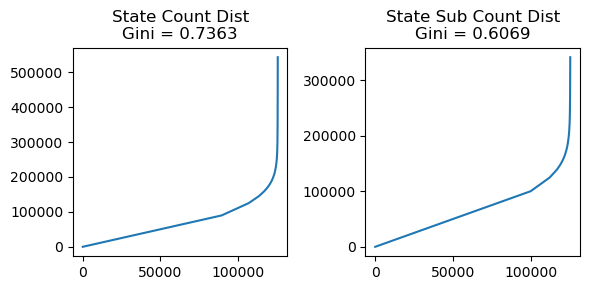

In [59]:
# 1 基于 raw state 的分析
state_action_raw = target.apply(lambda row: (row['State'], row['Action']), axis=1)
state_action_counts = state_action_raw.value_counts()
state_counts = target['Post_State'].value_counts().sort_values()
state_sub_counts = target.groupby(['Uid', 'State']).size().groupby('State').count().sort_values()
print(f"Totally {len(state_action_raw)} Records in {level} map, with {len(state_counts)} unique States and {len(state_action_counts)} unique (State, Action) pairs")
for i in [1, 10, 100]:
    print(f"{(state_counts <= i).sum()} ({(state_counts <=i).mean():.2%}) States have less than {i} records, {(state_sub_counts <= i).sum()} ({(state_sub_counts <=i).mean():.2%}) States visited by less than {i} participnats")

fig, ax = plt.subplots(1, 2, figsize=(6, 3))
ax[0].plot(np.arange(len(state_counts)), state_counts.cumsum())
ax[0].set_title(f'State Count Dist\nGini = {calculate_gini(state_counts.values):.4f}')
ax[1].plot(np.arange(len(state_sub_counts)), state_sub_counts.cumsum())
ax[1].set_title(f'State Sub Count Dist\nGini = {calculate_gini(state_sub_counts.values):.4f}')  
plt.tight_layout()

entropy_state = target.groupby('State')['Action'].value_counts().groupby('State').apply(relative_entropy)


In [60]:
# 2 基于push chain的分析
chain_row_counts = target.Chain.value_counts()
chain_library = pd.DataFrame({
    'Chain': chain_row_counts.index,
    'Count': chain_row_counts.values,
    'Property_Chain': map(PushChain.property_chain, chain_row_counts.index),
    'Texture_Chain': map(PushChain.texture_chain, chain_row_counts.index),
    'GlobalID_Chain': map(PushChain.globalid_chain, chain_row_counts.index),
    'Complex_Chain': map(PushChain.complex_chain, chain_row_counts.index),
    'Full_Chain': map(PushChain.full_chain, chain_row_counts.index)
}).set_index('Chain')
# chain_library

In [56]:
chain_sub_counts[chain_sub_counts > 100]

abs_chain
(((c, 16),),)              346
(((s, 2),),)               485
(((d, 4), (s, 2)),)        627
(((d, 4),), ((s, 2),))     635
(((d, 4),),)              1078
dtype: int64

Totally 543101 Records in target map, with 223 unique Chains and 4858 unique raw Chains
23 (10.31%) Chains have less than 1 records, 28 (12.56%) Chains visited by less than 1 participnats
76 (34.08%) Chains have less than 10 records, 88 (39.46%) Chains visited by less than 10 participnats
161 (72.20%) Chains have less than 100 records, 179 (80.27%) Chains visited by less than 100 participnats
194 (87.00%) Chains have less than 500 records, 208 (93.27%) Chains visited by less than 500 participnats


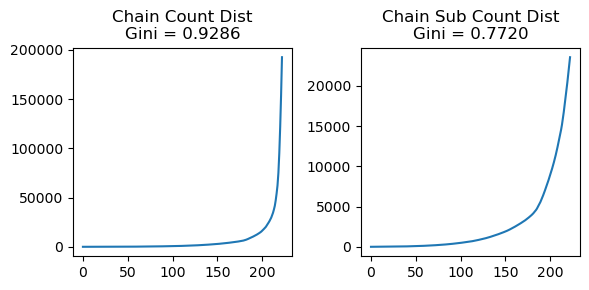

In [63]:
target.Chain.value_counts()
chain_of_interest = 'Complex_Chain'  # 'Property_Chain', 'Texture_Chain', 'GlobalID_Chain', 'Full_Chain'
target.loc[:, 'abs_chain'] = target.Chain.map(chain_library[chain_of_interest])
chain_counts = target.abs_chain.value_counts().sort_values()
chain_sub_counts = target.groupby(['Uid', 'abs_chain']).size().groupby('abs_chain').count().sort_values()
print(f"Totally {len(target)} Records in {level} map, with {len(chain_counts)} unique Chains and {len(target.Chain.value_counts())} unique raw Chains")
for i in [1, 10, 100, 500]:
    print(f"{(chain_counts <= i).sum()} ({(chain_counts <=i).mean():.2%}) Chains have less than {i} records, {(chain_sub_counts <= i).sum()} ({(chain_sub_counts <=i).mean():.2%}) Chains visited by less than {i} participnats")
fig, ax = plt.subplots(1, 2, figsize=(6, 3))
ax[0].plot(np.arange(len(chain_counts)), chain_counts.cumsum())
ax[0].set_title(f'Chain Count Dist\nGini = {calculate_gini(chain_counts.values):.4f}')
ax[1].plot(np.arange(len(chain_sub_counts)), chain_sub_counts.cumsum())
ax[1].set_title(f'Chain Sub Count Dist\nGini = {calculate_gini(chain_sub_counts.values):.4f}')  
plt.tight_layout()

In [ ]:
# 3 基于转移关系划分最简状态等价类（暂时没啥用）
state_root_record = {s: None for s in target.Post_State.unique()}
init_state = State(env.mm(level)).get_str()
state_root_record[init_state] = init_state

for j, exam in env.em.iter_epoch(level):
    for i, row in exam.iterrows():
        s, ns, c = row['State'], row['Post_State'], row['Chain']
        if PushChain.complex_chain(c) is np.nan:
            state_root_record[ns] = state_root_record[s]
        elif state_root_record[ns] is None:
            state_root_record[ns] = ns


Iterating map target with 1118 ids.


In [43]:
pd.Series(state_root_record).value_counts()

S-3afd2ff6f53fce8a    204
S-04847e5f98597cdb    189
S-60f924e6035df57b    178
S-b5cb865eb73144df    169
S-48e0a4fdad5e38b6    168
                     ... 
S-4fffd77a3b59ae11      1
S-9f577a831eb6e1aa      1
S-4c75cb8605456dcd      1
S-e35a06bc70463bd0      1
S-2785f770e05b8f0a      1
Name: count, Length: 41909, dtype: int64

## A3 从 State 到 Configuration
- 根据 Operator Space 划分 State 等价类

In [44]:
# 4 按照Operator Space划分状态等价类
for i, s in enumerate(target.Post_State.unique()):
    if dm.get_gamestate(s).get('outcome') == 'Continue':
        try:
            State(key = s).expand('units', force=True)
        except Exception as e:
            print(f"Error expanding state {s}: {e}")

    if i % 100 == 0:
        print(i, end = ' ')
    if i % 1000 == 0:
        print()

0 
100 200 300 400 500 600 700 800 900 1000 
1100 1200 1300 1400 1500 1600 1700 1800 1900 2000 
2100 2200 2300 2400 2500 2600 2700 2800 2900 3000 
3100 3200 3300 3400 3500 3600 3700 3800 3900 4000 
4100 4200 4300 4400 4500 4600 4700 4800 4900 5000 
5100 5200 5300 5400 5500 5600 5700 5800 5900 6000 
6100 6200 6300 6400 6500 6600 6700 6800 6900 7000 
7100 7200 7300 7400 7500 7600 7700 7800 7900 8000 
8100 8200 8300 8400 8500 8600 8700 8800 8900 9000 
9100 9200 9300 9400 9500 9600 9700 9800 9900 10000 
10100 10200 10300 10400 10500 10600 10700 10800 10900 11000 
11100 11200 11300 11400 11500 11600 11700 11800 11900 12000 
12100 12200 12300 12400 12500 12600 12700 12800 12900 13000 
13100 13200 13300 13400 13500 13600 13700 13800 13900 14000 
14100 14200 14300 14400 14500 14600 14700 14800 14900 15000 
15100 15200 15300 15400 15500 15600 15700 15800 15900 16000 
16100 16200 16300 16400 16500 16600 16700 16800 16900 17000 
17100 17200 17300 17400 17500 17600 17700 17800 17900 18000 
18100 1

In [ ]:
_complex_chain_cache = dict(zip(chain_library.index, chain_library['Complex_Chain']))
def get_complex_chain(raw_chain):
    if raw_chain in _complex_chain_cache:
        return _complex_chain_cache[raw_chain]
    result = PushChain.complex_chain(raw_chain)
    chain_library.loc[raw_chain, 'Chain'] = raw_chain
    chain_library.loc[raw_chain, 'Count'] = 0
    chain_library.loc[raw_chain, 'Complex_Chain'] = result
    _complex_chain_cache[raw_chain] = result
    return result

def trans2chain(trans_key):
    return dm.get_target(trans_key).get('push_chain')

def state2opspace(state_key):
    state = dm.get_gamestate(state_key)
    if state.get('units') is not None and state.get('outcome') == 'Continue':
        identity = pd.Series(map(trans2chain, decoding(state['units']).keys()))
        return sorted(identity.map(PushChain.complex_chain))
    return np.nan

def state2opspace_simple(state_key):
    state = dm.get_gamestate(state_key)
    if state.get('units') is not None and state.get('outcome') == 'Continue':
        identity = pd.Series(map(trans2chain, decoding(state['units']).keys()))
        return tuple(sorted(identity.map(PushChain.complex_chain).unique()))
    return np.nan

In [47]:
states = target.Post_State.unique()
op_space_state = pd.Series({s: state2opspace_simple(s) for s in states}, name='Op_Space')

Totally 543101 Records in target map, with 1554 unique equal Operator Space
258 (16.60%) Op Space have less than 1 records, 566 (79.55%) States visited by less than 1 participnats
330 (21.24%) Op Space have less than 2 records, 796 (89.29%) States visited by less than 2 participnats
695 (44.72%) Op Space have less than 10 records, 1255 (97.95%) States visited by less than 10 participnats
1269 (81.66%) Op Space have less than 100 records, 1506 (99.74%) States visited by less than 100 participnats
1459 (93.89%) Op Space have less than 500 records, 1549 (99.94%) States visited by less than 500 participnats


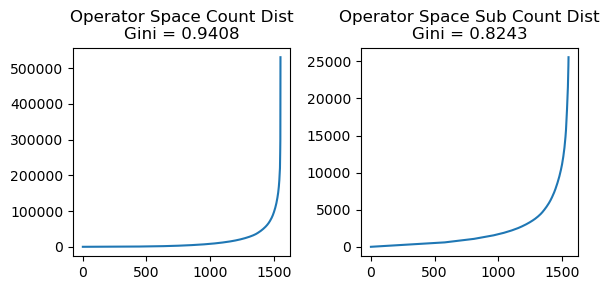

In [48]:

target['OP_Space'] = target.State.map(op_space_state)
space_counts = target.OP_Space.value_counts().sort_values()
space_sub_counts = target.groupby(['OP_Space', 'Uid']).size().groupby('OP_Space').count().sort_values()
print(f"Totally {len(target)} Records in {level} map, with {len(space_counts)} unique equal Operator Space")
for i in [1, 2, 10, 100, 500]:
    print(f"{(space_counts <= i).sum()} ({(space_counts <=i).mean():.2%}) Op Space have less than {i} records, {(space_sub_counts <= i).sum()} ({(state_sub_counts <=i).mean():.2%}) States visited by less than {i} participnats")

fig, ax = plt.subplots(1, 2, figsize=(6, 3))
ax[0].plot(np.arange(len(space_counts)), space_counts.cumsum())
ax[0].set_title(f'Operator Space Count Dist\nGini = {calculate_gini(space_counts.values):.4f}')
ax[1].plot(np.arange(len(space_sub_counts)), space_sub_counts.cumsum())
ax[1].set_title(f'Operator Space Sub Count Dist\nGini = {calculate_gini(space_sub_counts.values):.4f}')  
plt.tight_layout()


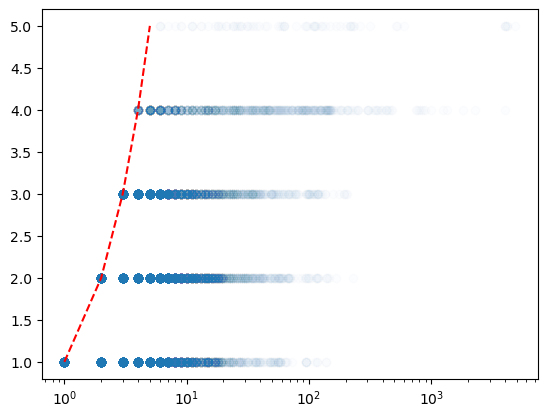

In [119]:
plt.scatter(visit, choice, alpha = 0.01)
plt.plot(np.arange(1, 6), np.arange(1, 6), color='red', linestyle='--')
plt.xscale('log')


# B Operator Description and Prediction

- 1 整理 Operator Level 的表格，每一行是 configuration, 记录了 state, op space, op choice, length, 和一些关键步骤的RT
- 2 分析 op 序列，例如重复性，对 fresh（第一次见/第一次选） 是否有偏好
- 3 建模 op 选择，到you距离，到win距离的启发式，对 fresh 的追求，restart 的影响等

# 1 Hierarchy of plans

In [6]:
def win_or_not(Uid):
    return dm.get_gamestate(dm.get_plan(dm.get_plan(str(Uid)))['post_state'])['outcome'] == 'Win'

def traj_summary(Map, Uid):
    test = env.em(Map, Uid)
    return {
    'Uid': test.Uid.unique()[0],
    'Map': test.Map.unique()[0],
    'Win': win_or_not(Uid), 

    'N_step': test.Count.max(),
    'N_unit': test.Unit_idx.max(),
    'N_chunk': test.Chunk_idx.max(),
    'N_seq': test.Seq_idx.max(),
    'N_subgoal': test.Subgoal_idx.max(),

    'Total_RT': test.Before.sum(),
    'Mean_RT': test.Before.mean(),
    'Std_RT': test.Before.std(),
    'Median_RT': test.Before.median(),
    'Mean_PD': test.pred_weighted.mean(),
    'Std_PD': test.pred_weighted.std(),
    'Mean_Exe': test.pred_Exe.mean(),
    'Mean_Pre': test.pred_Pre.mean(),
    'Mean_Post': test.pred_Post.mean(),
    'Mean_Plan': test.pred_Plan.mean(),

    'N_state': test.Grid.nunique(),
    'N_op': test.chain.nunique(), 
    'U_op': test.chain.unique()
    }

summary_list = []
for map in ALL_MAP:
    print(f"Processing Map: {map}")
    map_df = env.em.rebuild_total_df(map=map)
    dm = get_data_manager(f'../recording/{map}')
    for Uid in map_df.Uid.unique():
        summary_list.append(traj_summary(map, Uid))
    summary_df = pd.DataFrame.from_dict(summary_list)


Processing Map: intro
Processing Map: tutorial
Processing Map: base
Processing Map: target
Processing Map: maze
Processing Map: make
Processing Map: break
Processing Map: helper


In [60]:
summ = summary_df[summary_df.Map.isin(['intro', 'tutorial', 'base', 'target'])].copy()
summ.groupby(['Map', 'Win'])['Mean_RT'].std()

Map       Win  
base      False    342.899039
          True     217.747118
intro     True     913.945330
target    False    362.244673
          True     218.224210
tutorial  True     417.641972
Name: Mean_RT, dtype: float64

In [70]:
_win_lookup = summ.set_index(['Uid', 'Map'])['Win']

def is_win(row):
    return _win_lookup.get((row['Uid'], row['Map']), False)
df4 = df[df.Map.isin(['intro', 'tutorial', 'base', 'target'])].copy()
df4['Win'] = df4.apply(is_win, axis=1)

In [78]:
df4.groupby(['Map', 'Win', 'Subgoal_idx']).last()['chain'].groupby(['Map', 'Win']).nunique()

Map       Win  
base      False    36
          True     34
intro     True     34
target    False    35
          True     29
tutorial  True     21
Name: chain, dtype: int64

In [240]:
chain = env.em.rebuild_total_df('base')['chain']
counts = chain.value_counts()
counts[counts > 100]

chain
{}                                                                  174890
{0:[(d,k,4)]}                                                        36135
{0:[(w,k,4)];1:[(w,k,4)];2:[(w,k,4)]}                                23067
{0:[(s,k,4)]}                                                        13043
()                                                                    4568
                                                                     ...  
{0:[(d,1,32)];1:[(d,k,64)]}                                            119
{0:[(d,k,4)|(d,g,8)];1:[(d,g,8)]}                                      118
{0:[(w,k,4)];1:[(w,#,16)]}                                             112
{0:[(d,K,32)];1:[(d,0,32)];2:[(d,1,32)];3:[(d,k,4)];4:[(d,g,8)]}       108
{0:[(s,k,4)];1:[(s,k,4)];2:[(s,k,4)];3:[(s,#,16)]}                     101
Name: count, Length: 89, dtype: int64

In [192]:
test.chain

0                                           {}
1                                           {}
2                                           {}
3                                {0:[(s,p,4)]}
4                                {0:[(s,p,4)]}
5                                           {}
6                                           {}
7                                           {}
8     {0:[(d,D,32)];1:[(d,0,32)];2:[(d,3,32)]}
9                                           {}
10                               {0:[(w,p,4)]}
11                               {0:[(w,p,4)]}
12                                          {}
13                                          {}
14                               {0:[(w,p,4)]}
15                               {0:[(d,d,2)]}
Name: chain, dtype: object

In [ ]:
def count_map_states(map: str):
    real_states = defaultdict(lambda: defaultdict(int))  # 统计state occurance
    real_plan = defaultdict(lambda: defaultdict(int))

    for key in env.em.rebuild_total_df(map)['Grid']:
        # 过程中
        real_states['Step'][key] += 1
    
    dm = get_data_manager(f'../recording/{map}')
    for uid in env.em.rebuild_total_df(map)['Uid'].unique():
        # 获胜
        uplan = dm.get_plan(str(uid))
        real_states['Step'][dm.get_plan(uplan)['post_state']] += 1

        for level in ['Unit', 'Chunk', 'Seq', 'Subgoal', 'Full']:
            for item in Plan.iter(uplan, level):
                real_plan[level][item['key']] += 1
                real_states[level][item['post_state']] += 1
    real_plan['Step'] = real_states['Step'].copy()
    print(f'Map {map}: {len(real_states['Step'])} unique states encountered.')
    return real_states, real_plan

def assess_map_states(map: str):
    real_states, real_plan = count_map_states(map)
    record1 = {'states': len(real_states['Step'])}
    record2 = {'states': len(real_states['Step'])}
    for level in ['Unit', 'Chunk', 'Seq', 'Subgoal', 'Full']:
        record1[level.lower() + '_post'] = len(real_states[level])
        record1[level.lower() + '_ratio'] = len(real_states[level]) / len(real_states['Step'])
        record2[level.lower() + '_plan'] = len(real_plan[level])
        record2[level.lower() + '_ratio'] = len(real_plan[level]) / len(real_states['Step'])
    return record1, record2, real_plan, real_states

# 统计
post_record, plan_record, raw_plan, raw_post = {}, {}, {}, {}
for map in ALL_MAP:
    post_record[map], plan_record[map], raw_plan[map], raw_post[map] = assess_map_states(map)

Map intro: 5099 unique states encountered.
Map tutorial: 7795 unique states encountered.
Map base: 135107 unique states encountered.
Map target: 125720 unique states encountered.
Map maze: 6460 unique states encountered.
Map make: 2429 unique states encountered.
Map break: 8454 unique states encountered.
Map helper: 73056 unique states encountered.


In [103]:

def collect_one_plan(level: str, uid: int):
    exam0 = env.em(level, uid)
    state0 = env.mm(level)[1]
    plan0 = state0.to_plan(exam0.Action)
    plan_iterater = {}
    level_counter = defaultdict(int)
    for level in ['Unit', 'Chunk', 'Seq', 'Subgoal']:
        plan_iterater[level] = Plan.iter(plan0.key, level)
        exam0[level] = None
        exam0[f'{level}_idx'] = None
    exam0['Hierachy'] = plan0.coding()

    for i, row in exam0.iterrows():

        h = row['Hierachy'].split(',')
        if h[4] == '0':
            exam0.loc[i, 'Unit'] = next(plan_iterater['Unit'])['key']
            level_counter['Unit'] += 1

        if h[3] == '0' and h[4] == '0':
            exam0.loc[i, 'Chunk'] = next(plan_iterater['Chunk'])['key']
            level_counter['Chunk'] += 1

        if h[2] == '0' and h[3] == '0' and h[4] == '0':
            exam0.loc[i, 'Seq'] = next(plan_iterater['Seq'])['key']
            level_counter['Seq'] += 1

        if h[1] == '0' and h[2] == '0' and h[3] == '0' and h[4] == '0':
            exam0.loc[i, 'Subgoal'] = next(plan_iterater['Subgoal'])['key']
            level_counter['Subgoal'] += 1

        for level in ['Unit', 'Chunk', 'Seq', 'Subgoal']:
            exam0.loc[i, f'{level}_idx'] = level_counter[level]

def collect_all_plan():
    for map in ALL_MAP:
        print(f'Collecting plans for map {map}...')
        dm = get_data_manager(f'../recording/{map}')
        for uid in env.em.rebuild_total_df(map)['Uid'].unique():
            collect_one_plan(map, uid)
        
collect_all_plan()



In [459]:
# df = env.em.rebuild_total_df()
# df.sort_values(['Uid', 'Count_Global']).to_csv('../data/full_1119.csv', index=False)
env.init_experience('../data/full_1119.csv')
df = env.em.rebuild_total_df().sort_values(['Uid', 'Count_Global'])

In [11]:
df.groupby(['Uid', 'Unit_idx']).first()['Before'].groupby(['Uid']).mean().mean()

np.float64(677.62907869411)

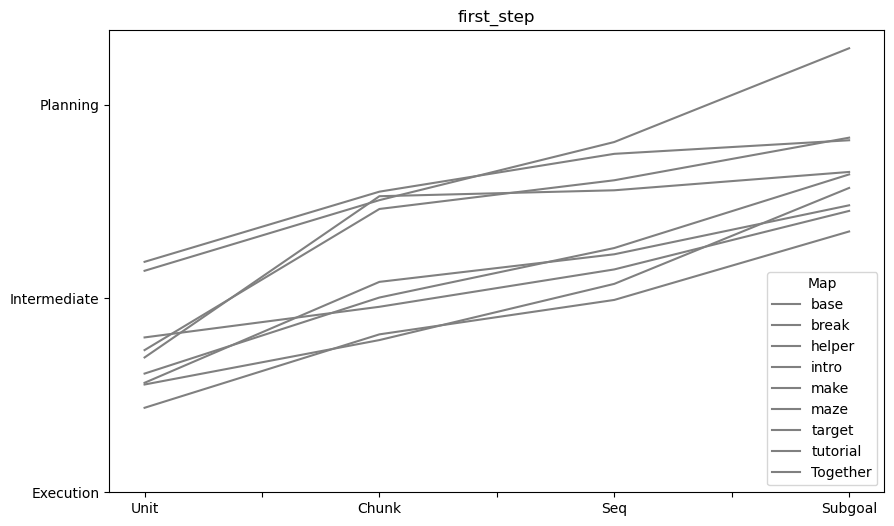

In [27]:
ax = plt.figure(figsize=(10, 6)).add_subplot(111)
record = pd.DataFrame()
y = 'pred_weighted'
for concern in ['Unit', 'Chunk', 'Seq', 'Subgoal']:
    record[concern] = df.groupby(['Map', 'Uid', f'{concern}_idx']).first()[y].groupby([f'Uid', 'Map']).mean().groupby('Map').mean()
    record.loc['Together', concern] = df.groupby(['Uid', f'{concern}_idx']).first()[y].groupby('Uid').mean().mean()
record.T.plot(title = 'first_step', ax = ax, color = 'grey')

ax.set_yticks([0.5, 1, 1.5], labels=['Execution', 'Intermediate', 'Planning'])

In [36]:
df.groupby(['Map', 'Uid'])['Before'].mean().groupby('Map').mean()

Map
base         606.279930
break        517.394803
helper       648.962976
intro       1230.256944
make         461.949689
maze         559.007731
target       599.025178
tutorial     927.761488
Name: Before, dtype: float64

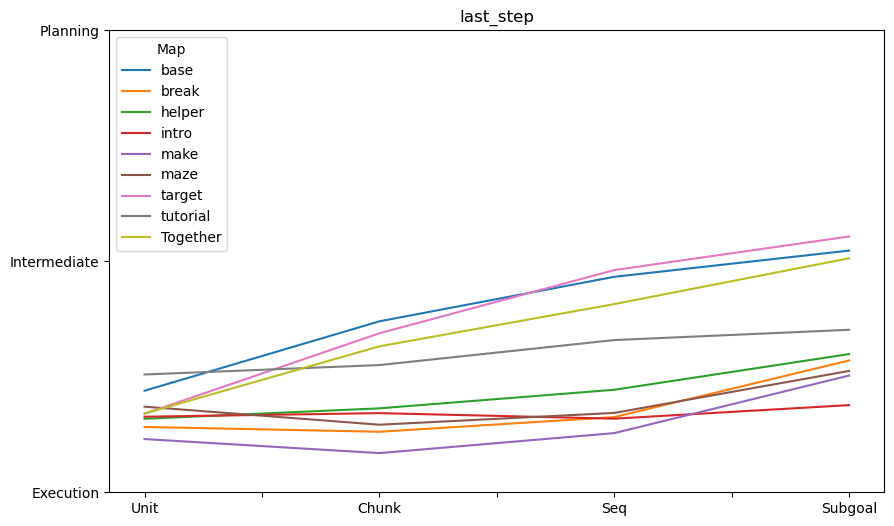

In [26]:
ax = plt.figure(figsize=(10, 6)).add_subplot(111)
record = pd.DataFrame()
for concern in ['Unit', 'Chunk', 'Seq', 'Subgoal']:
    record[concern] = df.groupby(['Map', 'Uid', f'{concern}_idx']).last()[y].groupby([f'Uid', 'Map']).mean().groupby('Map').mean()
    record.loc['Together', concern] = df.groupby(['Uid', f'{concern}_idx']).last()[y].groupby('Uid').mean().mean()
record.T.plot(title = 'last_step', ax = ax)

ax.set_yticks([0.5, 1, 1.5], labels=['Execution', 'Intermediate', 'Planning'])

# 2 Group by "Action Space"

In [4]:
def grid_to_inter(grid: str):
    units = State(key=grid).expand('units')
    for k in units.keys():
        if not isinstance(k, tuple) and len(k) == 3:
            print(f'Unexpected unit key: {k} in grid {grid}')
    return tuple(sorted(units.keys()))

def inter_to_hash(inter: tuple):
    inter_str = encoding(inter)
    return hashlib.sha256(inter_str.encode('utf-8')).hexdigest()[:16]

def plan_key_to_inter(plan_key: str):
    plan = decoding(dm.get_plan(plan_key)['subplans'])
    return plan if plan else ()


In [5]:
map = 'tutorial'
dm = get_data_manager(f'../recording/{map}')
map_data = env.em.rebuild_total_df(map)
unit_data = map_data[~map_data.Unit.isna()].copy()
grid_to_inter_dict = {}
for i, grid in enumerate(unit_data['Grid'].unique()):
    grid_to_inter_dict[grid] = grid_to_inter(grid)
    if (i+1) % 1000 == 0:
        print(i+1, end = ' ')
# dm.save_all()

1000 2000 3000 

In [6]:
def analyze_grid_units(df, map_name='intro'):
    dm = get_data_manager(f'../recording/{map_name}')
    map_data = df[df.Map == map_name]
    unit_data = map_data[~map_data.Unit.isna()].copy()
    print(f'Analyzing map {map_name} with {len(unit_data)} records...')

    unit_data.loc[:, 'Inter'] = unit_data['Grid'].apply(lambda grid: grid_to_inter_dict[grid])
    unit_data.loc[:, 'SimpleUnit'] = unit_data['Unit'].apply(plan_key_to_inter)

        # first_visit: 该Grid是否为该被试首次访问
    unit_data.loc[:, 'first_visit'] = ~unit_data.groupby('Uid')['Grid'].apply(
        lambda s: s.duplicated()).values
    
    print(f'Found {len(unit_data)} records with unit information.')

    grid_stats = []
    for inter, group in unit_data.groupby('Inter'):
        first_group = group[group['first_visit']]
        notfirst_group = group[~group['first_visit']]
        stats = {
            'InterTuple': inter,
            'InterHash': inter_to_hash(inter),
            'InterCount': len(inter),
            'Grids': group['Grid'].tolist(),
            'total_visit': len(group),
            'unique_units': group['SimpleUnit'].nunique(),
            'unit_counts': group['SimpleUnit'].value_counts().to_dict(), 
            'first_unit_counts': first_group['SimpleUnit'].value_counts().to_dict() if len(first_group) > 0 else {},
            'notfirst_unit_counts': notfirst_group['SimpleUnit'].value_counts().to_dict() if len(notfirst_group) > 0 else {},
        
        }
        grid_stats.append(stats)
    df = pd.DataFrame(grid_stats)
    df.set_index('InterHash', inplace=True)
    return df.sort_values('total_visit', ascending=False)

# 使用函数
grid_analysis = analyze_grid_units(df, 'tutorial')


Analyzing map tutorial with 12219 records...
Found 12219 records with unit information.


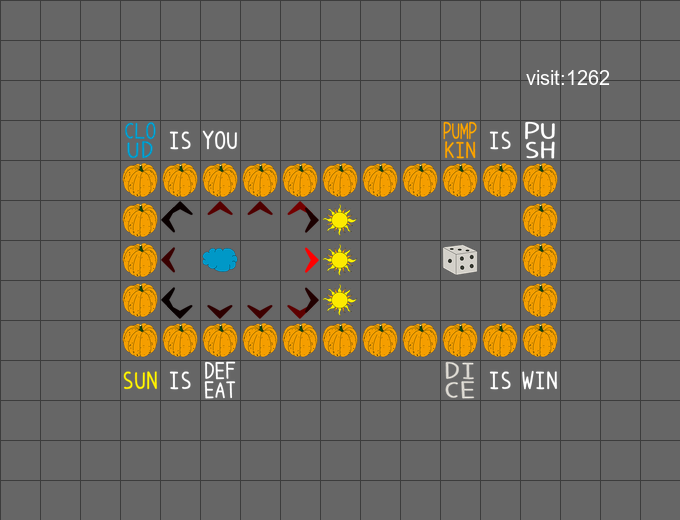

In [8]:
row = grid_analysis.iloc[0, :]
counts = row['first_unit_counts']
valid_counts = {k: v for k, v in counts.items() if len(k) > 1}
grid_with_choice(State(key=row['Grids'][0]).rebuild(), valid_counts, color = '#666666')


In [ ]:
all_figures = []
for _, row in grid_analysis.iterrows():
    if row['unique_units'] > 0 and row['total_visit'] > 100:
        grid = State(key = row['Grids'][0]).rebuild()  # 选择第一个格子进行展示
        unit_counts = {a: b for a, b in row['unit_counts'].items() if len(a) == 3}
        all_figures.append(grid_with_choice(grid, unit_counts))
len(all_figures)

# 3 Group by "Push Chain"

In [76]:
def push_chain(grid, action):
    if action in ['Up', 'Down', 'Left', 'Right']:
        action = getattr(Action, action.lower())
        state = State(key=grid)
        return state.to_trans(action)['push_chain']
    
def easy_chain(hard_chain):
    if hard_chain is None:
        return {}
    all_interaction = {}

    for you, chain in hard_chain.items():
        dir = you[2]
        pos = (you[0], you[1])
        you_inter = []
        current_group = []

        for inter in chain:
            npos = (inter[3], inter[4])
            if pos != npos:
                if current_group:
                    you_inter.append(current_group)
                current_group = []
                pos = npos
            current_group.append(encoding((dir, inter[1], inter[2])))
        if current_group:
            you_inter.append(current_group)
    all_interaction[you] = you_inter

    max_length = max(len(chain) for chain in all_interaction.values())
    result = {}
    for pos_idx in range(max_length):
        position_group = []
        for you, chain in all_interaction.items():
            if pos_idx < len(chain):
                position_group.extend(chain[pos_idx])
        if position_group:
            result[pos_idx] = position_group
    return encoding(result)

for map in ALL_MAP:
    print(f'Analyzing map {map}...')
    dm = get_data_manager(f'../recording/{map}')
    for uid in env.em.rebuild_total_df(map)['Uid'].unique():
        exam = env.em(map, uid)
        # exam.drop(columns = ['hard_chain', 'easy_chain'], inplace=True)
        exam.loc[:, 'chain'] = exam.apply(lambda row: easy_chain(push_chain(row['Grid'], row['Action'])), axis=1)

df = env.em.rebuild_total_df().sort_values(['Uid', 'Count_Global'])
df.to_csv('../data/full_1119.csv', index=False)

Analyzing map intro...
Analyzing map tutorial...
Analyzing map base...
Analyzing map target...
Analyzing map maze...
Analyzing map make...
Analyzing map break...
Analyzing map helper...


In [7]:
env.init_experience('../data/full_1119.csv')
df = env.em.rebuild_total_df().sort_values(['Uid', 'Count_Global'])

In [24]:
df.loc[:, 'len_chain'] = df['chain'].apply(lambda x: min(sum(len(v) for v in decoding(x).values()) if x != '{}' and x != '()' else 0, 2))


In [28]:
df.len_chain.value_counts()
df.groupby(['len_chain', 'Uid'])['pred_weighted'].mean()

len_chain  Uid 
0          0       0.784757
           1       0.605120
           2       0.677103
           3       0.728709
           4       0.639268
                     ...   
2          1113    0.627000
           1114    0.243365
           1115    1.042139
           1116    0.848520
           1117    0.774960
Name: pred_weighted, Length: 3354, dtype: float64

In [46]:
df[df.len_chain > 20].Grid

393357    S-326485a0ffa9b73d
393358    S-74fe2fa83bed0c82
393359    S-74fe2fa83bed0c82
393363    S-5dbcf5323c9f38d8
393368    S-2247e9b412b48be8
                 ...        
493202    S-5f29babd7c053f53
493203    S-b7299c409c37d632
505515    S-380f7769abf82a22
505523    S-6225d927fa223407
505524    S-ce610210a0b907d5
Name: Grid, Length: 1332, dtype: object

In [8]:
from util import encoding, decoding
def len_chain(row):
    if row['is_terminal']:
        return -1
    if row['chain'] == '{}' or row['chain'] == '()':
        return 0
    return min(sum(len(v) for v in decoding(row['chain']).values()), 2)

In [9]:

next_chain = df.groupby('Uid')['chain'].shift(-1)
df['is_terminal'] = next_chain.isna() | (next_chain == '()')
df['len_chain'] = df.apply(len_chain, axis=1)
df.groupby(['Uid','len_chain'])['pred_weighted'].mean().groupby('len_chain').mean()

len_chain
-1    0.789204
 0    0.734918
 1    0.590231
 2    0.690865
Name: pred_weighted, dtype: float64

In [10]:
# 定义标签映射
chain_labels = {0: 'Navigation', 1: 'Simple OP', 2: 'Complex OP', -1: 'Terminal OP'}

# 准备Current Step数据
current_planning = []
subjects = []
chain_types = []
timing = []

uids = df['Uid'].unique()
for uid in uids:
    uid_data = df[df['Uid'] == uid]
    for chain_val in [-1, 0, 1, 2]:
        chain_data = uid_data[uid_data['len_chain'] == chain_val]
        if len(chain_data) > 0:
            current_planning.append(chain_data['pred_weighted'].mean())
            subjects.append(uid)
            chain_types.append(chain_labels[chain_val])
            timing.append('Pre-OP')

# 准备Next Step数据
df_with_next = df.copy()
df_with_next['next_pred_weighted'] = df_with_next.groupby('Uid')['pred_weighted'].shift(-1).fillna(0)
next_planning_summary = df_with_next.groupby(['Uid', 'len_chain'])['next_pred_weighted'].mean().reset_index()

for _, row in next_planning_summary.iterrows():
    chain_val = int(row['len_chain'])
    if chain_val in [-1, 0, 1, 2]:
        current_planning.append(row['next_pred_weighted'])
        subjects.append(row['Uid'])
        chain_types.append(chain_labels[chain_val])
        timing.append('Post-OP')

# 合并数据并创建组合标签
combined_df = pd.DataFrame({
    'Subject': subjects,
    'ChainType': chain_types,
    'Timing': timing,
    'PlanningDepth': current_planning
})

# 创建组合标签：Current的3个在前，Next的3个在后
combined_df['CombinedLabel'] = combined_df['Timing'] + '\n' + combined_df['ChainType']


In [50]:
df['Restart_idx'] = df.groupby(['Map','Uid'])['chain'].transform(
    lambda x: (x == '()').cumsum() + 1)



In [61]:
# 定义层级映射
level = ['Unit', 'Chunk', 'Subgoal', 'Restart']
name = ['OP', 'Chunk', 'FU', 'Restart']

# 收集各层级首步和尾步数据
planning_data = []
subjects = []
level_types = []
timing = []

# 获取每个被试在每个层级的首步和尾步planning depth
uids = df['Uid'].unique()
for uid in uids:
    uid_data = df[df['Uid'] == uid]
    
    # 对每个层级进行分析
    for i, (lev, nm) in enumerate(zip(level, name)):
        # 首步planning depth
        first_data = uid_data.groupby(f'{lev}_idx').first()['pred_weighted']
        if len(first_data) > 0:
            planning_data.append(first_data.mean())
            subjects.append(uid)
            level_types.append(nm)
            timing.append('First')
            
        # 尾步planning depth
        last_data = uid_data.groupby(f'{lev}_idx').last()['pred_weighted']
        if len(last_data) > 0:
            planning_data.append(last_data.mean())
            subjects.append(uid)
            level_types.append(nm)
            timing.append('Last')

# 创建数据框
hierarchy_df = pd.DataFrame({
    'Subject': subjects,
    'Level': level_types,
    'Timing': timing,
    'PlanningDepth': planning_data
})


操作类型分析 Violin Plot 已保存为 CCNFig/thinking_during_navigation_violin.pdf


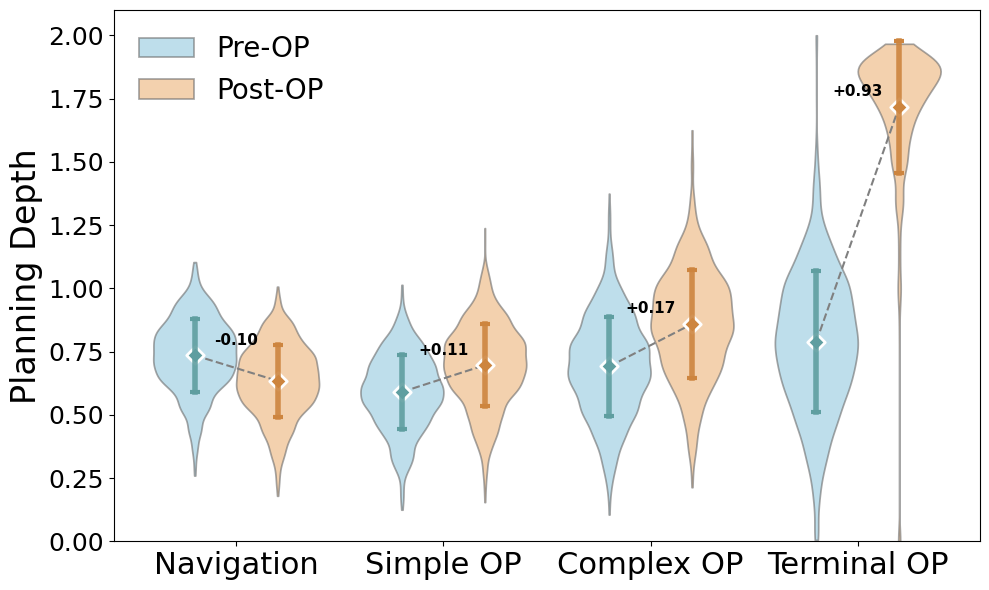

In [ ]:
# 导入统计分析库
from scipy import stats

# 统计量计算函数（与HMM图保持一致）
def calculate_stats(data):
    """计算均值和标准差"""
    mean = data.mean()
    std = data.std()
    return mean, std



# 统一的颜色方案 - 使用更协调的颜色
base_colors = ['#87CEEB', '#FFB366']  # 天空蓝和浅橙色
# 对应的深色版本，用于统计量标注
deeper_colors = ['#5F9EA0', '#CD853F']  # 更深的协调颜色

# 创建目录（如果不存在）
import os
os.makedirs('CCNFig', exist_ok=True)

# 第一个图：Chain Type Analysis (Current vs Next) - Thinking During Navigation (Violin Plot)
plt.figure(figsize=(10, 6))

# Violin plot显示分布
sns.violinplot(data=combined_df, x='ChainType', y='PlanningDepth', hue='Timing',
               order=['Navigation', 'Simple OP', 'Complex OP', 'Terminal OP'],
               palette=base_colors, alpha=0.6, inner=None, cut=0,
               bw_adjust=0.8, gridsize=200, density_norm='count')

# 添加统计量覆盖
chain_order = ['Navigation', 'Simple OP', 'Complex OP', 'Terminal OP']
timing_order = ['Pre-OP', 'Post-OP']

for i, chain_type in enumerate(chain_order):
    means = {}
    x_positions = {}
    for j, timing in enumerate(timing_order):
        subset = combined_df[(combined_df['ChainType'] == chain_type) & (combined_df['Timing'] == timing)]['PlanningDepth']
        if len(subset) > 1:
            mean, std = calculate_stats(subset)
            color = deeper_colors[j]
            
            # 计算violin的位置偏移
            x_pos = i + (j - 0.5) * 0.4  # 调整偏移量以匹配violin位置
            
            # 记录均值和位置，用于后续连线
            means[j] = mean
            x_positions[j] = x_pos
            
            # 添加均值点（深色菱形）
            plt.scatter(x_pos, mean, s=80, color=color, zorder=10, 
                       marker='D', edgecolor='white', linewidth=2)
            
            # 添加均值±标准差范围（深色粗线）
            std_low, std_high = mean - std, mean + std
            plt.plot([x_pos, x_pos], [std_low, std_high], 
                    color=color, linewidth=4, zorder=10, alpha=0.9)
            
            # 添加标准差端点
            plt.scatter([x_pos, x_pos], [std_low, std_high], s=60, color=color, 
                       zorder=10, marker='_', linewidth=3)
    
    # 在两组均值之间添加连线和差异标注
    if 0 in means and 1 in means:
        mid_x = (x_positions[0] + x_positions[1]) / 2
        max_y = max(means[0], means[1])
        diff = means[1] - means[0]
        plt.plot([x_positions[0], x_positions[1]], [means[0], means[1]], 
                 color='grey', linewidth=1.5, zorder=9, linestyle='--')
        plt.text(mid_x, max_y + 0.03, f'{diff:+.2f}', 
                 ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.ylabel('Planning Depth', fontsize=24)
plt.xlabel('', fontsize=24)
plt.ylim(0, 2.1)
# plt.grid(True, alpha=0.3, axis='y')
plt.legend(fontsize=20, loc='upper left', frameon=False)
plt.xticks(fontsize=22)
plt.yticks(fontsize=18)

plt.tight_layout()

# # 保存第一个图
plt.savefig('CCNFig/thinking_during_navigation_violin.pdf', transparent=True, dpi=300, bbox_inches='tight')
print("操作类型分析 Violin Plot 已保存为 CCNFig/thinking_during_navigation_violin.pdf")
plt.show()


In [54]:
hierarchy_df_display

,Subject,Level,Timing,PlanningDepth
0,0,Operator,Pre-OP,1.021048
1,0,Operator,Post-OP,0.756013
2,0,Chunk,Pre-OP,1.655840
3,0,Chunk,Post-OP,0.918953
4,0,Functional Unit,Pre-OP,1.691340
...,...,...,...,...
8939,1117,Chunk,Post-OP,0.878356
8940,1117,Functional Unit,Pre-OP,1.423182
8941,1117,Functional Unit,Post-OP,1.294568
8942,1117,Restart,Pre-OP,1.998750


层级分析 Violin Plot 已保存为 CCNFig/front_loaded_thinking_violin.pdf


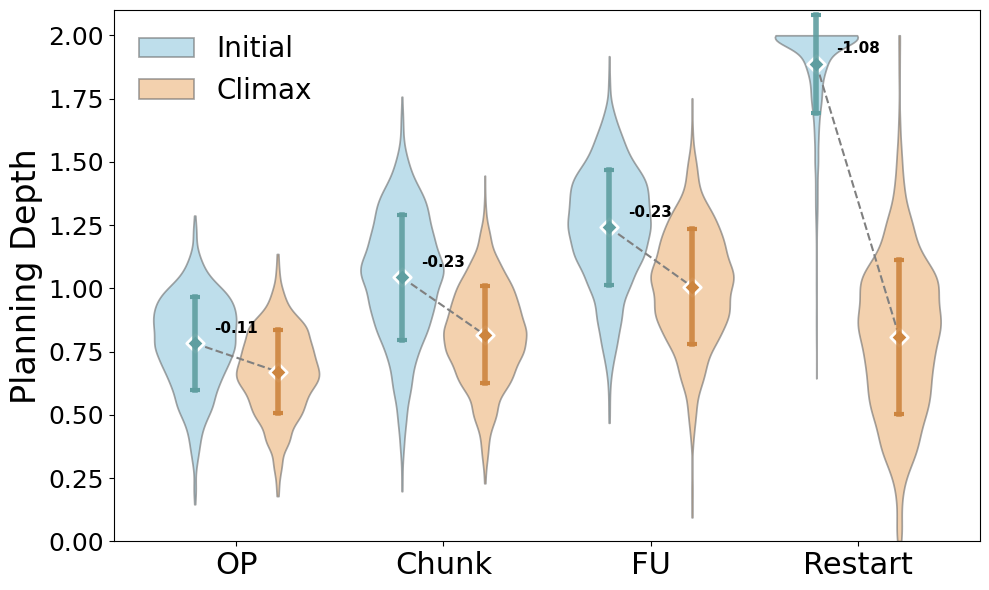

In [66]:
# 先修改hierarchy_df中的Timing标签
hierarchy_df_display = hierarchy_df.copy()
hierarchy_df_display['Timing'] = hierarchy_df_display['Timing'].map({'First': 'Initial', 'Last': 'Climax'})

# 第二个图：Hierarchy Analysis (First vs Last) - Front-loaded Thinking (Violin Plot)
plt.figure(figsize=(10, 6))

# Violin plot显示分布
sns.violinplot(data=hierarchy_df_display, x='Level', y='PlanningDepth', hue='Timing',
               order=['OP', 'Chunk', 'FU', 'Restart'],
               palette=base_colors, alpha=0.6, inner=None, cut=0,
               bw_adjust=0.8, gridsize=200, density_norm='count')

# 添加统计量覆盖
level_order = ['OP', 'Chunk', 'FU', 'Restart']
timing_order_hier = ['Initial', 'Climax']

for i, level_name in enumerate(level_order):
    means = {}
    x_positions = {}
    for j, timing in enumerate(timing_order_hier):
        subset = hierarchy_df_display[(hierarchy_df_display['Level'] == level_name) & (hierarchy_df_display['Timing'] == timing)]['PlanningDepth']
        if len(subset) > 1:
            mean, std = calculate_stats(subset)
            color = deeper_colors[j]
            
            # 计算violin的位置偏移
            x_pos = i + (j - 0.5) * 0.4
            
            # 记录均值和位置，用于后续连线
            means[j] = mean
            x_positions[j] = x_pos
            
            # 添加均值点（深色菱形）
            plt.scatter(x_pos, mean, s=80, color=color, zorder=10, 
                       marker='D', edgecolor='white', linewidth=2)
            
            # 添加均值±标准差范围（深色粗线）
            std_low, std_high = mean - std, mean + std
            plt.plot([x_pos, x_pos], [std_low, std_high], 
                    color=color, linewidth=4, zorder=10, alpha=0.9)
            
            # 添加标准差端点
            plt.scatter([x_pos, x_pos], [std_low, std_high], s=60, color=color, 
                       zorder=10, marker='_', linewidth=3)
    
    # 在两组均值之间添加连线和差异标注
    if 0 in means and 1 in means:
        mid_x = (x_positions[0] + x_positions[1]) / 2
        max_y = max(means[0], means[1])
        diff = means[1] - means[0]
        plt.plot([x_positions[0], x_positions[1]], [means[0], means[1]], 
                 color='grey', linewidth=1.5, zorder=9, linestyle='--')
        plt.text(mid_x, max_y + 0.03, f'{diff:+.2f}', 
                 ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.ylabel('Planning Depth', fontsize=24) 
plt.xlabel('', fontsize=24)
plt.ylim(0, 2.1)
plt.legend(fontsize=20, loc='upper left', frameon=False)
plt.xticks(fontsize=22)
plt.yticks(fontsize=18)

plt.tight_layout()

# 保存第二个图
plt.savefig('CCNFig/front_loaded_thinking_violin.pdf', transparent=True, dpi=300, bbox_inches='tight')
print("层级分析 Violin Plot 已保存为 CCNFig/front_loaded_thinking_violin.pdf")

plt.show()


In [513]:
intro = env.em.rebuild_total_df('target')
counts = intro.groupby('easy_chain').size().sort_values(ascending=False)
counts[counts > 100]

easy_chain
()                                                                          365111
((('d', 'M', 32),),)                                                         19523
((('w', 'M', 32),),)                                                         16140
((('w', 4, 32),),)                                                           15254
((('d', 4, 32),),)                                                           13675
                                                                             ...  
((('w', 0, 32),), (('w', 'M', 32),), (('w', 'p', 16),))                        108
((('d', 0, 32),), (('d', 4, 32), ('d', 'l', 8)))                               107
((('d', 'M', 32),), (('d', 4, 32),), (('d', 0, 32),))                          106
((('w', 0, 32),), (('w', 4, 32),), (('w', 'M', 32),), (('w', 'p', 16),))       101
((('d', 0, 32),), (('d', 4, 32),), (('d', 0, 32),))                            101
Length: 86, dtype: int64

# 4 Looking for new interactions

In [33]:
dm = get_data_manager(f'../recording/tutorial')


In [166]:
level = 'Unit'
unit_df = df.groupby(['Uid', 'Map', f'{level}_idx']).last()['chain'].reset_index()
unit_df['PD'] = df.groupby(['Uid', 'Map', f'{level}_idx']).first()['pred_maximum'].values

def classify_chain(group):
    labels = []
    seen = set()
    prev = None
    for chain in group['chain']:
        if prev is not None and chain == prev:
            labels.append('Repeat')
        elif chain in seen:
            labels.append('Reuse')
        else:
            labels.append('Explore')
        seen.add(chain)
        prev = chain
    return pd.Series(labels, index=group.index)

unit_df['chain_type'] = unit_df.groupby(['Uid', 'Map'], group_keys=False).apply(classify_chain)


C:\Users\asus\AppData\Local\Temp\ipykernel_10236\417235270.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  unit_df['chain_type'] = unit_df.groupby(['Uid', 'Map'], group_keys=False).apply(classify_chain)


In [167]:
# uniqueness: 1 - p，p = 该chain在该Map中出现过的被试比例
n_subjects_per_map = unit_df.groupby('Map')['Uid'].nunique()
chain_subject_count = unit_df.groupby(['Map', 'chain'])['Uid'].nunique().reset_index(name='n_sub')
chain_subject_count['p'] = chain_subject_count.apply(lambda r: r['n_sub'] / n_subjects_per_map[r['Map']], axis=1)
chain_subject_count['uniqueness'] = 1 - chain_subject_count['p']

# effectiveness: 赢了的被试选择该chain的比例 - 输了的被试选择该chain的比例
win_info = summary_df[['Uid', 'Map', 'Win']].drop_duplicates()
chain_uid = unit_df.groupby(['Map', 'chain'])['Uid'].apply(set).reset_index(name='uid_set')

eff_rows = []
for _, row in chain_uid.iterrows():
    m, ch, uid_set = row['Map'], row['chain'], row['uid_set']
    map_win = win_info[(win_info['Map'] == m)]
    win_uids = set(map_win[map_win['Win'] == True]['Uid'])
    lose_uids = set(map_win[map_win['Win'] == False]['Uid'])
    p_win = len(uid_set & win_uids) / len(win_uids) if len(win_uids) > 0 else 0
    p_lose = len(uid_set & lose_uids) / len(lose_uids) if len(lose_uids) > 0 else 0
    eff_rows.append({'Map': m, 'chain': ch, 'effectiveness': p_win - p_lose})

eff_df = pd.DataFrame(eff_rows)
chain_subject_count = chain_subject_count.merge(eff_df, on=['Map', 'chain'], how='left')

unit_df = unit_df.merge(chain_subject_count[['Map', 'chain', 'uniqueness', 'effectiveness']], on=['Map', 'chain'], how='left')
unit_df

,Uid,Map,Unit_idx,chain,PD,chain_type,uniqueness,effectiveness
0,0,base,1,"{0:[(w,k,4)];1:[(w,k,4)];2:[(w,k,4)]}",3,Explore,0.004472,-0.004789
1,0,base,2,"{0:[(w,k,4)];1:[(w,k,4)];2:[(w,k,4)]}",0,Repeat,0.004472,-0.004789
2,0,base,3,"{0:[(w,k,4)];1:[(w,k,4)];2:[(w,k,4)]}",1,Repeat,0.004472,-0.004789
3,0,base,4,"{0:[(w,k,4)];1:[(w,k,4)];2:[(w,k,4)]}",1,Repeat,0.004472,-0.004789
4,0,base,5,"{0:[(w,k,4)];1:[(w,k,4)];2:[(w,k,4)]}",1,Repeat,0.004472,-0.004789
...,...,...,...,...,...,...,...,...
497779,1117,tutorial,4,"{0:[(a,p,4)]}",0,Repeat,0.799642,0.200358
497780,1117,tutorial,5,"{0:[(w,p,4)]}",3,Explore,0.178891,0.821109
497781,1117,tutorial,6,"{0:[(w,p,4)]}",1,Repeat,0.178891,0.821109
497782,1117,tutorial,7,"{0:[(w,p,4)]}",1,Repeat,0.178891,0.821109


In [168]:
colors = ['#f0e4a0', '#95d1b0', '#95d1b0', '#c8b9e0']  # Plan, Post, Pre, Exe
deeper_colors = ['#d4c466', '#6bb387', '#6bb387', '#a896c7']  # 更深的协调颜色
label_order = {3: 'Plan\nPD=2', 2:'Post\nPD=1', 1:'Pre\nPD=1', 0:'Exe\nPD=0'}
unit_df.groupby(['PD', 'Uid'])['effectiveness'].mean().groupby('PD').mean(), unit_df.groupby(['PD'])['effectiveness'].mean()
# unit_df.groupby(['PD', 'Uid'])['uniqueness'].mean().groupby('PD').mean(), unit_df.groupby(['PD'])['uniqueness'].mean()

(PD
 0   -0.131816
 1   -0.113385
 2   -0.104203
 3   -0.092781
 Name: effectiveness, dtype: float64,
 PD
 0   -0.149841
 1   -0.136735
 2   -0.126419
 3   -0.118253
 Name: effectiveness, dtype: float64)

Chain novelty by PD violin 已保存


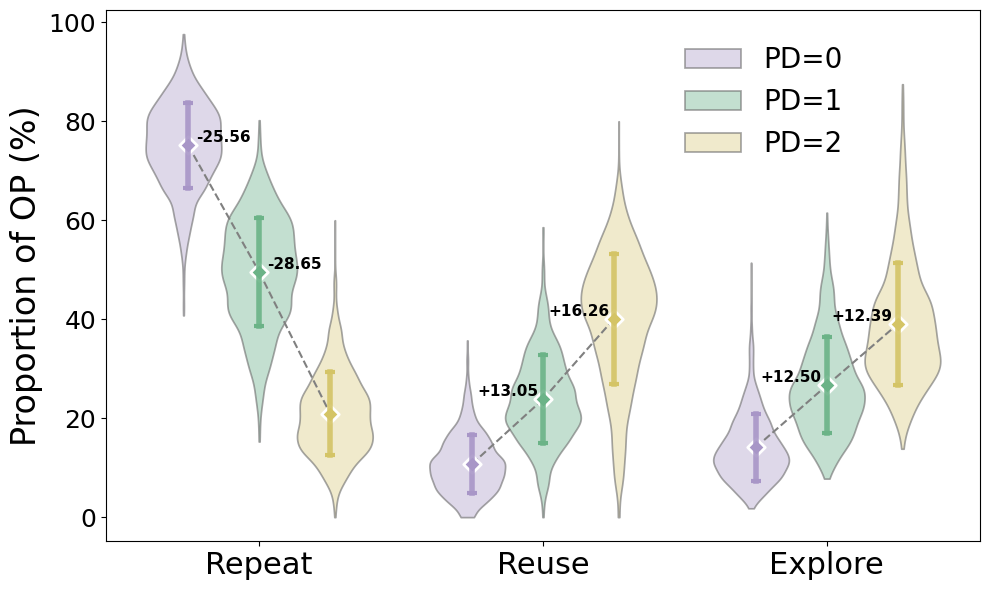

In [169]:
# 3×3 Violin: chain_type × PD(合并为3水平)，按被试计算每种chain_type的比例
chain_type_order = ['Repeat', 'Reuse', 'Explore']

# PD: 0→Exe(紫), 1&2→Think(绿), 3→Plan(黄)
pd_merge = {0: 'PD=0', 1: 'PD=1', 2: 'PD=1', 3: 'PD=2'}
hue_order = ['PD=0', 'PD=1', 'PD=2']
pd_colors_map = {'PD=0': '#c8b9e0', 'PD=1': '#95d1b0', 'PD=2': '#f0e4a0'}
pd_deeper_map = {'PD=0': '#a896c7', 'PD=1': '#6bb387', 'PD=2': '#d4c466'}

# 合并PD水平后重新计算比例
unit_df_m = unit_df.copy()
unit_df_m['PD_label'] = unit_df_m['PD'].map(pd_merge)

all_combos = pd.MultiIndex.from_product(
    [unit_df_m['Uid'].unique(), hue_order, chain_type_order],
    names=['Uid', 'PD_label', 'chain_type']
)
counts = unit_df_m.groupby(['Uid', 'PD_label', 'chain_type']).size().reindex(all_combos, fill_value=0).reset_index(name='count')
totals = unit_df_m.groupby(['Uid', 'PD_label']).size().reset_index(name='total')
violin_data = counts.merge(totals, on=['Uid', 'PD_label'])
violin_data['proportion'] = violin_data['count'] / violin_data['total'] * 100

# --- 绘图 ---
fig, ax = plt.subplots(figsize=(10, 6))

sns.violinplot(data=violin_data, x='chain_type', y='proportion', hue='PD_label',
               order=chain_type_order, hue_order=hue_order,
               palette=pd_colors_map, alpha=0.6, inner=None, cut=0,
               bw_adjust=0.8, gridsize=200, density_norm='count', ax=ax)

# 统计量覆盖：均值菱形 + 均值±标准差 + 连线Δ
n_hue = len(hue_order)
offsets = np.linspace(-0.25, 0.25, n_hue)

for i, ct in enumerate(chain_type_order):
    prev_mean, prev_x = None, None
    for j, pd_label in enumerate(hue_order):
        subset = violin_data[(violin_data['chain_type'] == ct) & (violin_data['PD_label'] == pd_label)]['proportion']
        if len(subset) > 1:
            mean = subset.mean()
            std = subset.std()
            color = pd_deeper_map[pd_label]
            x_pos = i + offsets[j]

            ax.scatter(x_pos, mean, s=80, color=color, zorder=10,
                      marker='D', edgecolor='white', linewidth=2)
            std_low, std_high = mean - std, mean + std
            ax.plot([x_pos, x_pos], [std_low, std_high],
                   color=color, linewidth=4, zorder=10, alpha=0.9)
            ax.scatter([x_pos, x_pos], [std_low, std_high], s=60, color=color,
                      zorder=10, marker='_', linewidth=3)

            if prev_mean is not None:
                mid_x = (prev_x + x_pos) / 2
                diff = mean - prev_mean
                ax.plot([prev_x, x_pos], [prev_mean, mean],
                       color='grey', linewidth=1.5, zorder=9, linestyle='--')
                max_y = max(prev_mean, mean)
                ax.text(mid_x, max_y + 0.01, f'{diff:+.2f}',
                       ha='center', va='bottom', fontsize=11, fontweight='bold')

            prev_mean, prev_x = mean, x_pos

ax.set_ylabel('Proportion of OP (%)', fontsize=24)
ax.set_xlabel('', fontsize=24)
ax.legend(fontsize=20, loc=[0.65, 0.7], frameon=False)
ax.tick_params(axis='x', labelsize=22)
ax.tick_params(axis='y', labelsize=18)
plt.tight_layout()
plt.savefig('CCNFig/chain_novelty_by_pd_violin.pdf', transparent=True, dpi=300, bbox_inches='tight')
print("Chain novelty by PD violin 已保存")
plt.show()

Uniqueness & Effectiveness violin 已保存


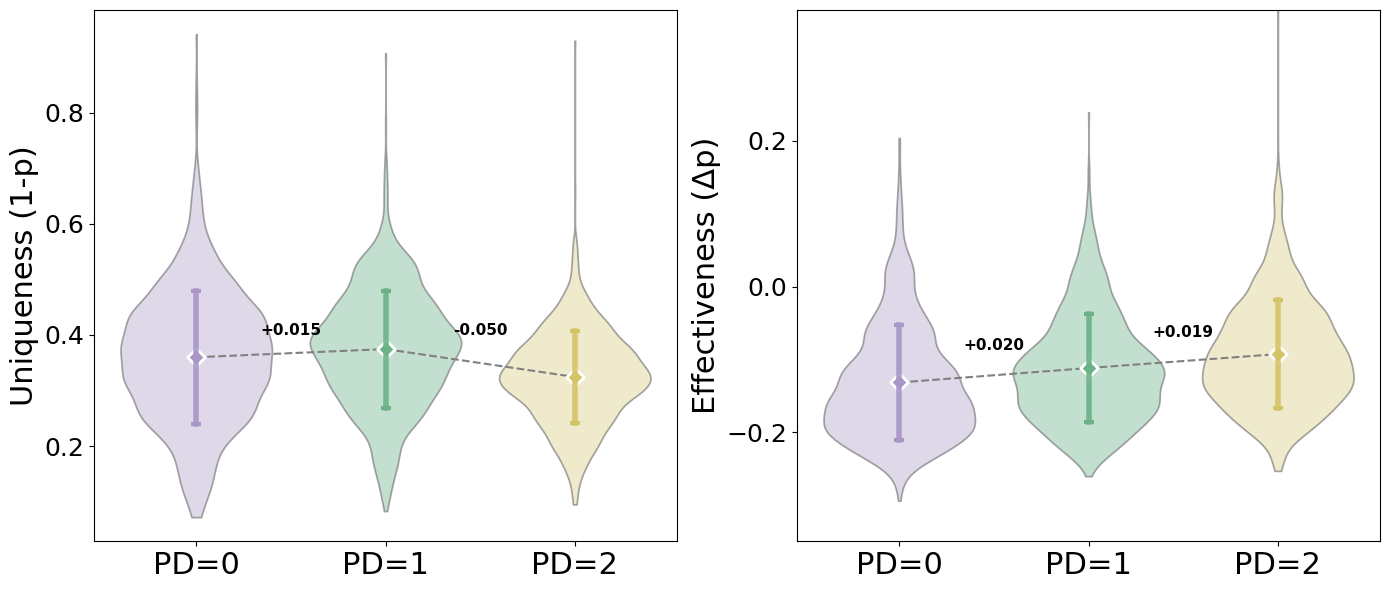

In [178]:
# Uniqueness & Effectiveness Violin: 按被试在每个PD水平下的均值
pd_merge = {0: 'PD=0', 1: 'PD=1', 2: 'PD=1', 3: 'PD=2'}
hue_order = ['PD=0', 'PD=1', 'PD=2']
pd_colors_map = {'PD=0': '#c8b9e0', 'PD=1': '#95d1b0', 'PD=2': '#f0e4a0'}
pd_deeper_map = {'PD=0': '#a896c7', 'PD=1': '#6bb387', 'PD=2': '#d4c466'}

unit_df_m = unit_df.copy()
unit_df_m['PD_label'] = unit_df_m['PD'].map(pd_merge)

# 按被试+PD水平计算uniqueness和effectiveness的均值
subj_means = unit_df_m.groupby(['Uid', 'PD_label'])[['uniqueness', 'effectiveness']].mean().reset_index()

metrics = [('uniqueness', 'Uniqueness (1-p)'), ('effectiveness', 'Effectiveness (Δp)')]
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (metric, ylabel) in zip(axes, metrics):
    sns.violinplot(data=subj_means, x='PD_label', y=metric, hue='PD_label',
                   order=hue_order, hue_order=hue_order,
                   palette=pd_colors_map, alpha=0.6, inner=None, cut=0,
                   bw_adjust=0.8, gridsize=200, density_norm='count', ax=ax, legend=False)

    offsets = [0] * len(hue_order)
    prev_mean, prev_x = None, None
    for j, pd_label in enumerate(hue_order):
        subset = subj_means[subj_means['PD_label'] == pd_label][metric]
        if len(subset) > 1:
            mean = subset.mean()
            std = subset.std()
            color = pd_deeper_map[pd_label]
            x_pos = j

            ax.scatter(x_pos, mean, s=80, color=color, zorder=10,
                      marker='D', edgecolor='white', linewidth=2)
            std_low, std_high = mean - std, mean + std
            ax.plot([x_pos, x_pos], [std_low, std_high],
                   color=color, linewidth=4, zorder=10, alpha=0.9)
            ax.scatter([x_pos, x_pos], [std_low, std_high], s=60, color=color,
                      zorder=10, marker='_', linewidth=3)

            if prev_mean is not None:
                mid_x = (prev_x + x_pos) / 2
                diff = mean - prev_mean
                ax.plot([prev_x, x_pos], [prev_mean, mean],
                       color='grey', linewidth=1.5, zorder=9, linestyle='--')
                max_y = max(prev_mean, mean)
                ax.text(mid_x, max_y + 0.02, f'{diff:+.3f}',
                       ha='center', va='bottom', fontsize=11, fontweight='bold')

            prev_mean, prev_x = mean, x_pos

    ax.set_ylabel(ylabel, fontsize=22)
    ax.set_xlabel('', fontsize=24)
    ax.tick_params(axis='x', labelsize=22)
    ax.tick_params(axis='y', labelsize=18)

# 右图yticks稀疏
axes[1].yaxis.set_major_locator(plt.MultipleLocator(0.2))
axes[1].set_ylim(-0.35,0.38)

plt.tight_layout()
plt.savefig('CCNFig/uniqueness_effectiveness_violin.pdf', transparent=True, dpi=300, bbox_inches='tight')
print("Uniqueness & Effectiveness violin 已保存")
plt.show()

In [160]:
subj_means.groupby('PD_label')['effectiveness'].mean(), subj_means.groupby('PD_label')['effectiveness'].std()

(PD_label
 PD=0   -0.131816
 PD=1   -0.111945
 PD=2   -0.092781
 Name: effectiveness, dtype: float64,
 PD_label
 PD=0    0.079054
 PD=1    0.074352
 PD=2    0.074529
 Name: effectiveness, dtype: float64)

In [158]:
import pingouin as pg

# 只保留三个PD水平都有数据的被试
subj_complete = subj_means.groupby('Uid').filter(lambda g: set(hue_order).issubset(set(g['PD_label'])))

for metric, label in [('uniqueness', 'Uniqueness'), ('effectiveness', 'Effectiveness')]:
    print(f"\n{'='*60}")
    print(f"  {label}")
    print(f"{'='*60}")

    # Friedman检验 (非参数重复测量)
    friedman = pg.friedman(data=subj_complete, dv=metric, within='PD_label', subject='Uid')
    print(f"\n--- Friedman Test ---")
    print(friedman.to_string())

    # 重复测量ANOVA
    rm = pg.rm_anova(data=subj_complete, dv=metric, within='PD_label', subject='Uid')
    print(f"\n--- Repeated Measures ANOVA ---")
    print(rm.to_string())

    # 事后两两比较 (Wilcoxon + Bonferroni)
    posthoc = pg.pairwise_tests(data=subj_complete, dv=metric, within='PD_label', subject='Uid',
                                 parametric=False, padjust='bonf')
    print(f"\n--- Pairwise Wilcoxon (Bonferroni) ---")
    print(posthoc.to_string())


  Uniqueness

--- Friedman Test ---
            Source        W  ddof1           Q         p_unc
Friedman  PD_label  0.17474      2  390.719141  1.433562e-85

--- Repeated Measures ANOVA ---
     Source  ddof1  ddof2          F          p_unc      p_GG_corr       ng2       eps  sphericity   W_spher       p_spher
0  PD_label      2   2234  285.52466  3.770155e-111  4.689859e-100  0.039495  0.897101       False  0.885299  2.993440e-30

--- Pairwise Wilcoxon (Bonferroni) ---
   Contrast     A     B  Paired  Parametric     W_val alternative         p_unc        p_corr p_adjust    hedges
0  PD_label  PD=0  PD=1    True       False  226884.0   two-sided  1.826548e-15  5.479644e-15     bonf -0.129846
1  PD_label  PD=0  PD=2    True       False  173339.0   two-sided  3.894485e-38  1.168345e-37     bonf  0.343916
2  PD_label  PD=1  PD=2    True       False   84474.0   two-sided  3.372375e-99  1.011712e-98     bonf  0.529026

  Effectiveness

--- Friedman Test ---
            Source         W  

In [171]:
# 根据定义的feature提取逻辑，批量处理所有unit生成DataFrame

def extract_unit_features(unit_key):
    """
    根据您定义的逻辑提取单个unit的所有feature
    """
    try:
        # 获取unit信息
        unit = dm.get_plan(unit_key)
        x, y, d = decoding(unit['subplans'])
        
        # 方向到向量的映射
        d2v = {'w': np.array((0, 1)), 'd': np.array((1, 0)), 
               's': np.array((0, -1)), 'a': np.array((-1, 0))}
        
        # 计算特征
        ran = 1  # 固定值（可能表示随机性）
        pos = np.array([x, y]) + d2v[d]  # 终点位置
        cost = unit['action_cost']  # 动作成本
        
        # 规则判断：在特定位置和方向时为1
        rule = 1 if (x, y, d) in [(5, 7, 'w'), (4, 7, 'w'), (5, 5, 's'), (4, 5, 's')] else 0
        
        # 危险判断：在特定位置和方向时为1  
        danger = 1 if (x, y, d) in [(5, 7, 'w'), (4, 7, 'w'), (7, 5, 'd'), (7, 4, 'd'), (7, 6, 'd')] else 0
        
        # 贪婪距离：到目标位置[11, 5]的曼哈顿距离
        greedy = sum(abs(pos - np.array([11, 5])))
        
        # 中心距离：到中心位置[8, 5]的曼哈顿距离
        central = sum(abs(pos - np.array([8, 5])))
        
        # 探索性：不在特定位置时为1
        explore = 1 if (x, y, d) not in [(7, 5, 'd'), (7, 4, 'd'), (7, 6, 'd')] else 0
        
        return {
            'unit_key': unit_key,
            'start_x': x,
            'start_y': y,
            'direction': d,
            'end_x': pos[0],
            'end_y': pos[1],
            'random': ran,
            'random_exploration': int(cost),
            'changing_rule': rule,
            'approach_danger': danger,
            'approach_win': greedy,
            'approach_central': central,
            'explore': explore,
            'frequency': count[unit_key] if unit_key in count.index else 0
        }
        
    except Exception as e:
        print(f"处理unit {unit_key} 时出错: {e}")
        return None





In [174]:
def nll(cols, beta=0, df_subset=None):
    """计算负对数似然"""
    if df_subset is None:
        df_subset = unit_features_df
    X = df_subset[cols].values
    y = df_subset['frequency'].values
    p = np.exp(beta * X) / sum(np.exp(beta * X))
    return -sum(y * np.log(p + 1e-10))

def fit(col, df_subset=None):
    """拟合单个特征并返回参数和R²"""
    from scipy.optimize import minimize
    if df_subset is None:
        df_subset = unit_features_df
    
    res = minimize(lambda beta: nll(col, beta, df_subset), x0=0.0, bounds=[(-10, 10)])
    r2 = 1 - nll(col, res.x, df_subset) / nll(col, 0, df_subset)
    return res.x[0], r2

# 准备数据：分别处理Count==0和Count!=0的情况
state0 = env.mm('tutorial')[1]
base_data = df[df.Grid == state0.key][~df.Unit.isna()]
base_data = base_data[~base_data.Unit.str.contains('r')]

# Count != 0 的数据
t0_nonzero = base_data[base_data.Count != 0]
count_nonzero = t0_nonzero['Unit'].value_counts()

# Count == 0 的数据
t0_zero = base_data[base_data.Count == 0]
count_zero = t0_zero['Unit'].value_counts()


# 为Count != 0的数据提取特征
unit_features_list_nonzero = []
for unit_key in count_nonzero.index:
    features = extract_unit_features(unit_key)
    if features:
        features['frequency'] = count_nonzero[unit_key]
        unit_features_list_nonzero.append(features)
unit_features_df_nonzero = pd.DataFrame(unit_features_list_nonzero)

# 为Count == 0的数据提取特征
unit_features_list_zero = []
for unit_key in count_zero.index:
    features = extract_unit_features(unit_key)
    if features:
        features['frequency'] = count_zero[unit_key]
        unit_features_list_zero.append(features)
unit_features_df_zero = pd.DataFrame(unit_features_list_zero)

# 要拟合的特征列表
features_to_fit = ['random_exploration', 'changing_rule', 'approach_danger', 'approach_win', 'approach_central']

# 存储结果的字典
results = {
    'Feature': [],
    'Count_NonZero_Beta': [],
    'Count_NonZero_R2': [],
    'Count_Zero_Beta': [],
    'Count_Zero_R2': []
}

print("\n=== 开始拟合分析 ===")

# 对每个特征进行拟合
for feature in features_to_fit:
    
    # 拟合Count != 0的数据
    if len(unit_features_df_nonzero) > 0:
        try:
            beta_nonzero, r2_nonzero = fit(feature, unit_features_df_nonzero)
            print(f"  Count != 0: Beta = {beta_nonzero:.4f}, R² = {r2_nonzero:.4f}")
        except Exception as e:
            print(f"  Count != 0 拟合失败: {e}")
            beta_nonzero, r2_nonzero = np.nan, np.nan
    else:
        beta_nonzero, r2_nonzero = np.nan, np.nan
    
    # 拟合Count == 0的数据
    if len(unit_features_df_zero) > 0:
        try:
            beta_zero, r2_zero = fit(feature, unit_features_df_zero)
            print(f"  Count == 0: Beta = {beta_zero:.4f}, R² = {r2_zero:.4f}")
        except Exception as e:
            print(f"  Count == 0 拟合失败: {e}")
            beta_zero, r2_zero = np.nan, np.nan
    else:
        beta_zero, r2_zero = np.nan, np.nan
    
    # 存储结果
    results['Feature'].append(feature)
    results['Count_NonZero_Beta'].append(beta_nonzero)
    results['Count_NonZero_R2'].append(r2_nonzero)
    results['Count_Zero_Beta'].append(beta_zero)
    results['Count_Zero_R2'].append(r2_zero)

# 创建结果表格
results_df = pd.DataFrame(results)




=== 开始拟合分析 ===
  Count != 0: Beta = -0.5278, R² = 0.0259
  Count == 0: Beta = -0.0178, R² = 0.0000
  Count != 0: Beta = 0.2676, R² = 0.0030
  Count == 0: Beta = -0.7345, R² = 0.0162
  Count != 0: Beta = 0.1861, R² = 0.0014
  Count == 0: Beta = 0.8160, R² = 0.0302
  Count != 0: Beta = -0.0277, R² = 0.0007
  Count == 0: Beta = -0.2215, R² = 0.0439
  Count != 0: Beta = -0.0277, R² = 0.0007
  Count == 0: Beta = -0.2215, R² = 0.0439


C:\Users\asus\AppData\Local\Temp\ipykernel_59536\140420259.py:22: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  base_data = df[df.Grid == state0.key][~df.Unit.isna()]


In [187]:
604/1226

0.4926590538336052

In [186]:
from scipy.stats import entropy
entropy(count_nonzero.values), entropy(count_zero.values)

(np.float64(2.3339137113818196), np.float64(2.0831355721001703))

In [168]:
def nll(cols, beta=0):
    X = unit_features_df[cols].values
    y = unit_features_df['frequency'].values
    p = np.exp(beta * X) / sum(np.exp(beta * X))
    return -sum(y * np.log(p + 1e-10))

def fit(col):
    from scipy.optimize import minimize
    res = minimize(lambda beta: nll(col, beta), x0=0.0, bounds=[(-10, 10)])
    r2 = 1 - nll(col, res.x) / nll(col)
    return res.x, r2

state0 = env.mm('tutorial')[1]
t0 = df[df.Grid == state0.key][~df.Unit.isna()]
t0 = t0[~t0.Unit.str.contains('r')][t0.Count != 0]
count = t0['Unit'].value_counts()

unit_features_list = []
for i, unit_key in enumerate(count.index):
    features = extract_unit_features(unit_key)
    if features:
        unit_features_list.append(features)
unit_features_df = pd.DataFrame(unit_features_list)

fit('cost')

C:\Users\asus\AppData\Local\Temp\ipykernel_59536\1555899004.py:14: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  t0 = df[df.Grid == state0.key][~df.Unit.isna()]
C:\Users\asus\AppData\Local\Temp\ipykernel_59536\1555899004.py:15: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  t0 = t0[~t0.Unit.str.contains('r')][t0.Count != 0]


(array([-0.52777255]), np.float64(0.025876876999440857))

In [22]:
counts = env.em.rebuild_total_df('target').chain.value_counts().sort_values(ascending=False)
counts.head(40)

chain
{}                                                               351389
{0:[(d,M,32)]}                                                    19523
{0:[(w,M,32)]}                                                    16140
{0:[(w,4,32)]}                                                    15254
()                                                                13722
{0:[(d,4,32)]}                                                    13675
{0:[(a,p,16)]}                                                    12576
{0:[(d,0,32)]}                                                    12063
{0:[(w,0,32)]}                                                    12004
{0:[(w,p,16)]}                                                     7461
{0:[(d,M,32)];1:[(d,0,32)];2:[(d,4,32)]}                           6663
{0:[(s,#,16)]}                                                     4826
{0:[(w,#,16)]}                                                     3219
{0:[(w,M,32)];1:[(w,p,16)]}                               

In [183]:
from scipy.stats import entropy
count_nonzero

Unit
Unit_S-733f9f61ada581ce_[(5,7,w)]    154
Unit_S-733f9f61ada581ce_[(5,5,s)]    148
Unit_S-733f9f61ada581ce_[(4,6,a)]    137
Unit_S-733f9f61ada581ce_[(7,6,d)]     96
Unit_S-733f9f61ada581ce_[(7,7,w)]     93
Unit_S-733f9f61ada581ce_[(7,5,s)]     89
Unit_S-733f9f61ada581ce_[(6,5,s)]     51
Unit_S-733f9f61ada581ce_[(6,7,w)]     48
Unit_S-733f9f61ada581ce_[(7,5,d)]     43
Unit_S-733f9f61ada581ce_[(7,7,d)]     37
Unit_S-733f9f61ada581ce_[(4,5,a)]     14
Unit_S-733f9f61ada581ce_[(4,7,w)]     12
Unit_S-733f9f61ada581ce_[(4,7,a)]      8
Unit_S-733f9f61ada581ce_[(4,5,s)]      8
Name: count, dtype: int64

In [46]:
def cal_entropy(a):
    seq = a[a>0]
    record = []
    for i in range(1, len(seq)+1):
        counts = pd.Series(seq[:i]).value_counts()
        record.append((entropy(counts), np.log2(i)))
    return np.array(record)

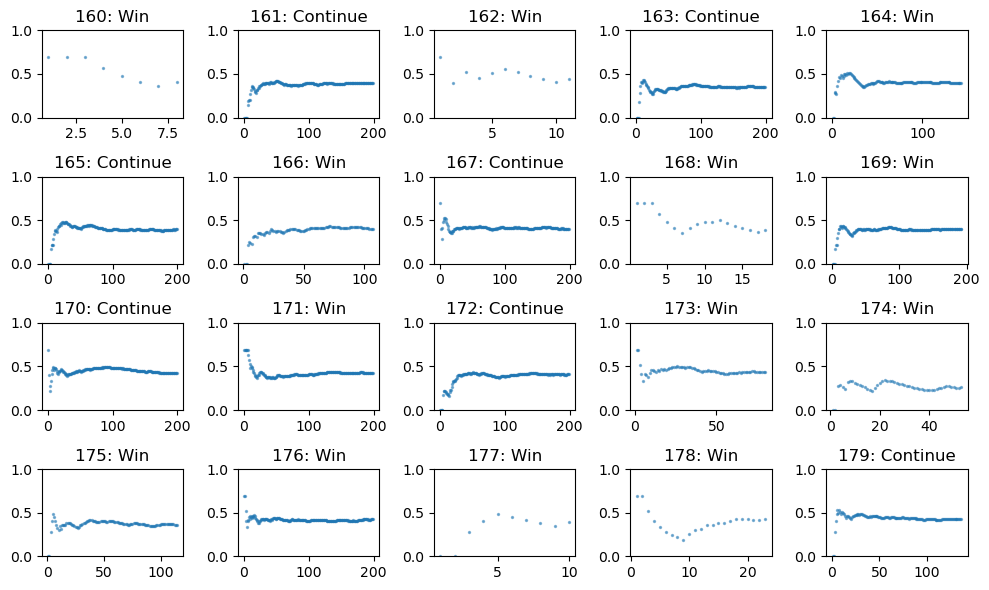

In [54]:
fig, ax = plt.subplots(4, 5, figsize=(10, 6))
ax = ax.flatten()
N = 200
for i in range(20):
    a, b = env.em('target', i + base).chain.factorize()
    x = np.arange(1, min(len(a[a>0]), N))
    ent = cal_entropy(a)
    ax[i].scatter(x, ent[1:N, 0]/ent[1:N, 1], s=2, alpha = 0.5)
    ax[i].set_title(f'{i + base}: {win_or_not("target", i + base)["outcome"]}')
    ax[i].set_ylim(0, 1)
plt.tight_layout()
base += 20

In [58]:
exam = env.em('target', 0).chain
[a for a in exam.to_list() if len(a) > 0]


chain
[[(d,M,32)]]                                                 45
[[(d,4,32)]]                                                 35
[[(w,M,32)]]                                                 33
[[(w,4,32)]]                                                 31
[[(d,0,32)]]                                                 27
                                                             ..
[]                                                            1
[]                                                            1
[[(d,M,32), (d,l,8)], [(d,0,32)], [(d,4,32)], [(d,m,16)]]     1
[[(d,M,32), (d,l,8)], [(d,0,32)], [(d,4,32)], [(d,m,16)]]     1
[]                                                            1
Name: count, Length: 725, dtype: int64

Win


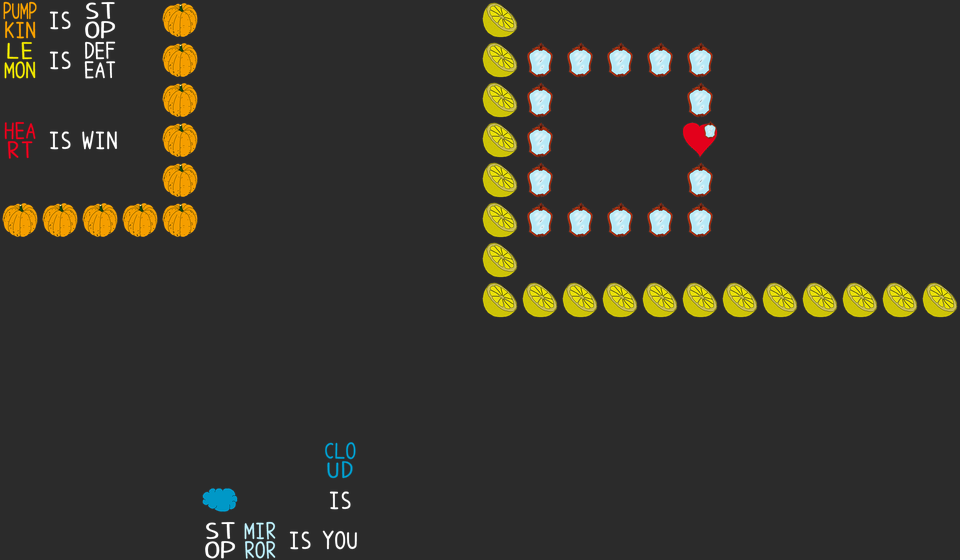

In [412]:
subID = 15
final = State(key = dm.get_plan(dm.get_plan(str(subID)))['post_state'])
print(final['outcome'])
final.show()


In [12]:
grid_analysis.head(10)

,InterTuple,InterCount,Grids,total_visit,unique_units,unit_counts
InterHash,,,,,,
e372ab8b542a836f,"((0, 7, w), (1, 1, d), (1, 7, w), (2, 0, w), (...",46,"[S-3afd2ff6f53fce8a, S-eb4fb58e5958ad0a, S-eb4...",36195,139,"{(5, 10, 'a'): 3460, (8, 3, 's'): 1925, (5, 9,..."
2e38e77b22c314a4,(),0,"[S-cd0b81b43e11479e, S-07f65a580bbc416e, S-cde...",12885,2,"{(-2, -2, 'r'): 7321, (-2, -2, 'z'): 5564}"
2e59c9491f688506,"((0, 7, w), (1, 7, w), (2, 7, w), (3, 7, w), (...",38,"[S-1303ee0358ae8571, S-d68e0f8da7c78bf2, S-60f...",7464,157,"{(11, 10, 'd'): 1079, (11, 7, 'd'): 507, (11, ..."
43e547d09ce13a8f,"((0, 7, w), (1, 7, d), (1, 7, w), (2, 1, d), (...",46,"[S-771dc68ed17da63c, S-771dc68ed17da63c, S-771...",2324,48,"{(2, 6, 'w'): 1524, (1, 7, 'd'): 317, (3, 0, '..."
e64248a46e25bfdd,"((0, 7, w), (1, 2, d), (1, 7, w), (2, 1, d), (...",48,"[S-e61525bb0a0049ce, S-e61525bb0a0049ce, S-e61...",1698,16,"{(2, 1, 'w'): 1249, (1, 2, 'd'): 339, (3, 0, '..."
ca81956e1f534d84,"((0, 7, w), (1, 1, d), (1, 7, w), (2, 0, w), (...",48,"[S-a95a471fd9243cf7, S-a95a471fd9243cf7, S-a95...",1483,29,"{(4, 1, 'w'): 1253, (3, 0, 'w'): 62, (4, 1, 'a..."
b2f7006fe07d6e67,"((0, 7, w), (1, 1, d), (1, 7, w), (2, 0, w), (...",48,"[S-728a086a0c538495, S-728a086a0c538495, S-728...",1333,34,"{(4, 2, 'w'): 1010, (3, 3, 'd'): 53, (3, 0, 'w..."
c4dc9fd2a2c065fb,"((0, 7, w), (1, 3, d), (1, 7, w), (2, 1, d), (...",48,"[S-b4c1c43f8dc96543, S-b4c1c43f8dc96543, S-b4c...",1275,13,"{(2, 2, 'w'): 1037, (1, 3, 'd'): 99, (2, 4, 's..."
6421306a1d5d97cf,"((0, 7, w), (1, 7, w), (2, 7, w), (3, 7, w), (...",40,"[S-0cd6858ae3cb5c62, S-ad5be0a14741ee51, S-ad5...",1191,40,"{(17, 4, 'w'): 939, (16, 5, 'd'): 40, (18, 5, ..."


In [ ]:
# 如何定义等价状态
## 1 exactly the same layout on grid level ~ 600k
## 2 

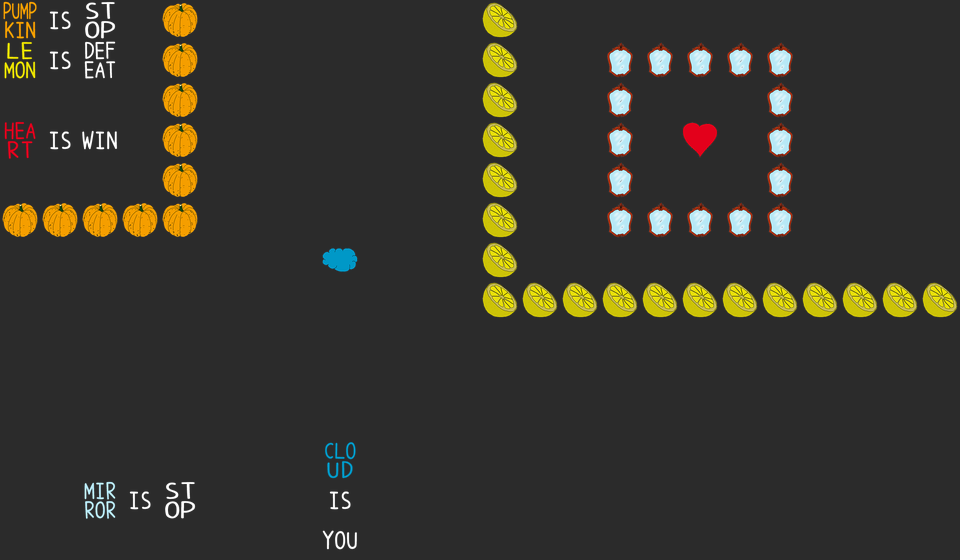

In [292]:
state0 = env.mm('target')[1]
state0.to_unit('sss').plan.post_state.show()

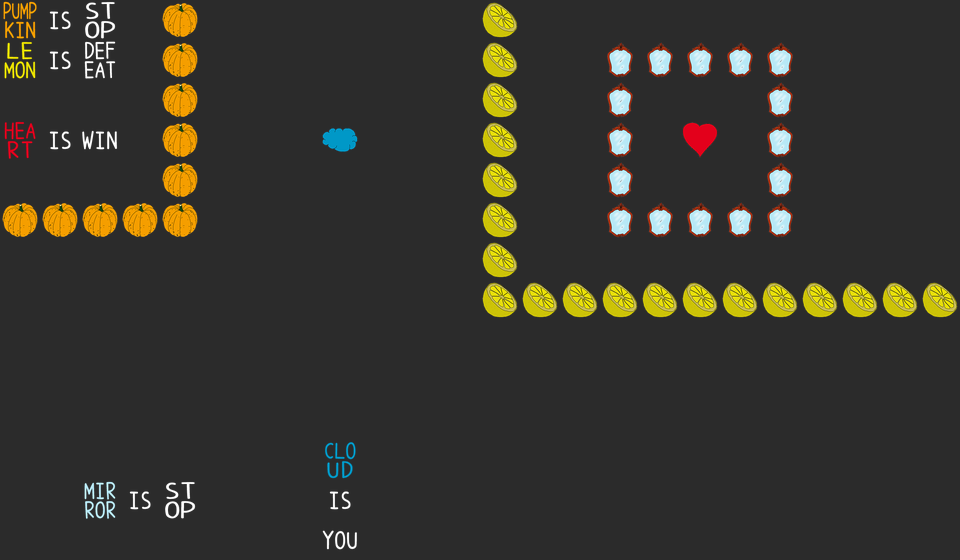

In [274]:
state0.show()

In [293]:
'S-17443cad0a0d4576' in df.Grid

False

In [240]:
State(key = 'S-17443cad0a0d4576').expand('units')

{(5, 0, 'd'): 'd',
 (15, 7, 's'): 'ss',
 (16, 7, 's'): 'ss',
 (17, 9, 'w'): 'ww',
 (17, 7, 's'): 'ss',
 (18, 7, 's'): 'ss',
 (19, 7, 's'): 'ss',
 (5, 1, 'a'): 'wa',
 (4, 0, 'w'): 'aw',
 (16, 10, 'd'): 'dd',
 (18, 10, 'a'): 'aa',
 (17, 11, 's'): 'ss',
 (14, 7, 's'): 'sas',
 (13, 8, 'a'): 'aaa',
 (20, 7, 's'): 'sds',
 (13, 9, 'a'): 'aaa',
 (6, 1, 's'): 'wds',
 (13, 10, 'a'): 'aaa',
 (13, 11, 'a'): 'aaa',
 (13, 12, 'a'): 'aaa',
 (13, 7, 's'): 'saas',
 (13, 7, 'a'): 'saaa',
 (21, 7, 's'): 'sdds',
 (4, 2, 's'): 'wwas',
 (7, 1, 's'): 'wdds',
 (7, 1, 'd'): 'wddd',
 (3, 1, 'd'): 'aawd',
 (13, 13, 'a'): 'waaa',
 (22, 7, 's'): 'sddds',
 (7, 2, 'd'): 'wwddd',
 (23, 7, 's'): 'sdddds',
 (8, 3, 's'): 'wwwddds',
 (5, 8, 'a'): 'wwwwwwwwa',
 (4, 7, 'w'): 'wwwwwwwaw',
 (9, 2, 'a'): 'wwwddddsa',
 (5, 9, 'a'): 'wwwwwwwwwa',
 (3, 7, 'w'): 'wwwwwwwaaw',
 (9, 1, 'a'): 'wwwddddssa',
 (5, 10, 'a'): 'wwwwwwwwwwa',
 (2, 7, 'w'): 'wwwwwwwaaaw',
 (9, 0, 'a'): 'wwwddddsssa',
 (5, 11, 'a'): 'wwwwwwwwwwwa',
 (1, 7, '

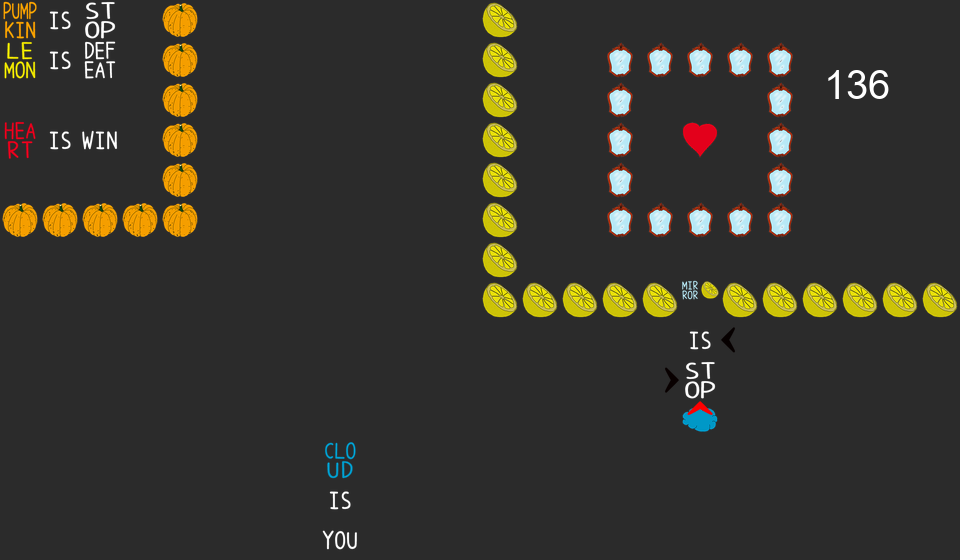

In [227]:
all_figures[110]

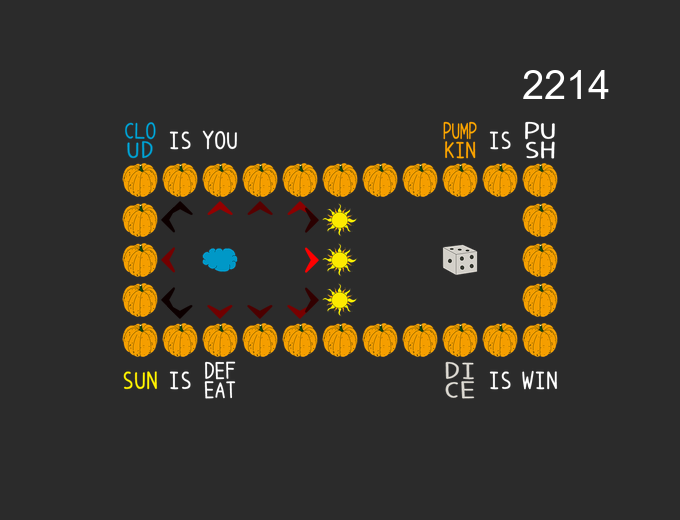

In [ ]:
grid_with_choice(state0.rebuild(), grid_analysis.unit_counts['2cdce5ef057cac49'])

In [321]:
figs = []
for grid, row in grid_analysis.iterrows():
    if row['unique_units'] > 2:
        fig = grid_with_choice(State(key=grid).rebuild(), row['unit_counts'])
        figs.append(fig)


In [331]:
State(key = state0).describe()['units'].keys()

dict_keys([(5, 7, 'w'), (5, 5, 's'), (4, 6, 'a'), (4, 7, 'w'), (4, 7, 'a'), (6, 7, 'w'), (4, 5, 's'), (4, 5, 'a'), (6, 5, 's'), (7, 6, 'd'), (7, 7, 'w'), (7, 7, 'd'), (7, 5, 's'), (7, 5, 'd')])

In [ ]:
Unit_S-0013f1ca8f267bdd_[(8,9,d)]

,Uid,Map,Count_Global,Count,Action,Before,After,pred_maximum,pred_weighted,pred_state_0,...,Grid,Hierachy,Unit,Unit_idx,Chunk,Chunk_idx,Seq,Seq_idx,Subgoal,Subgoal_idx
431,3,base,411,82,Undo,3249,2500,3,2.000,0.0,...,S-885397bb1a699ec7,"3,0,1,0,0","Unit_S-885397bb1a699ec7_[(-2,-2,z)]",49,"Chunk_S-885397bb1a699ec7_[(-2,-2,z)]",12,NaN,7,NaN,4
1387,8,base,346,21,Undo,3232,3449,3,2.000,0.0,...,S-597d4c54789f1885,"2,0,1,0,0","Unit_S-597d4c54789f1885_[(-2,-2,z)]",16,"Chunk_S-597d4c54789f1885_[(-2,-2,z)]",7,NaN,4,NaN,3
2502,11,base,663,79,Undo,2504,9690,3,1.982,0.0,...,S-d8aef9961894d68d,"1,0,1,0,0","Unit_S-d8aef9961894d68d_[(-2,-2,z)]",29,"Chunk_S-d8aef9961894d68d_[(-2,-2,z)]",11,NaN,6,NaN,2
2508,11,base,670,85,Undo,5344,2255,3,1.965,0.0,...,S-8e6d22db66ca5efb,"2,0,1,0,0","Unit_S-8e6d22db66ca5efb_[(-2,-2,z)]",31,"Chunk_S-8e6d22db66ca5efb_[(-2,-2,z)]",13,NaN,7,NaN,3
2514,11,base,677,91,Undo,1855,7834,3,1.933,0.0,...,S-d8aef9961894d68d,"3,0,1,0,0","Unit_S-d8aef9961894d68d_[(-2,-2,z)]",33,"Chunk_S-d8aef9961894d68d_[(-2,-2,z)]",15,NaN,8,NaN,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1236043,1077,tutorial,32,5,Undo,3665,1399,1,1.000,0.0,...,S-f5edd6e211d9ff77,"0,0,1,0,0","Unit_S-f5edd6e211d9ff77_[(-2,-2,z)]",2,"Chunk_S-f5edd6e211d9ff77_[(-2,-2,z)]",2,NaN,1,NaN,1
1236394,1093,tutorial,24,3,Undo,3488,700,3,2.000,0.0,...,S-f5edd6e211d9ff77,"0,0,1,0,0","Unit_S-f5edd6e211d9ff77_[(-2,-2,z)]",2,"Chunk_S-f5edd6e211d9ff77_[(-2,-2,z)]",2,NaN,1,NaN,1
1236634,1105,tutorial,18,3,Undo,4666,1784,1,1.000,0.0,...,S-f5edd6e211d9ff77,"0,0,1,0,0","Unit_S-f5edd6e211d9ff77_[(-2,-2,z)]",2,"Chunk_S-f5edd6e211d9ff77_[(-2,-2,z)]",2,NaN,1,NaN,1
1236665,1107,tutorial,24,3,Undo,3883,717,1,1.000,0.0,...,S-f5edd6e211d9ff77,"0,0,1,0,0","Unit_S-f5edd6e211d9ff77_[(-2,-2,z)]",2,"Chunk_S-f5edd6e211d9ff77_[(-2,-2,z)]",2,NaN,1,NaN,1


In [56]:
exam0['Hierachy']

0     0,0,0,0,0
1     0,0,0,0,1
2     0,0,0,0,2
3     0,0,0,1,0
4     0,0,1,0,0
5     0,1,0,0,0
6     0,0,0,0,0
7     0,0,0,0,1
8     1,0,0,0,0
9     1,0,0,0,1
10    1,0,0,0,2
11    1,0,0,1,0
12    1,0,0,2,0
13    1,0,0,3,0
14    1,0,0,4,0
15    1,0,0,5,0
Name: Hierachy, dtype: object

In [53]:
list(Plan.iter(plan0, 'Subgoal'))

[{'level': 'Subgoal',
  'pre_state': 'S-733f9f61ada581ce',
  'post_state': 'S-095cce1df6f367e1',
  'identity': '[(7,5,s)|(7,4,s)]',
  'subplans': '{0:Seq_S-733f9f61ada581ce_[(7,5,s)|(7,4,s)]}',
  'key': 'Subgoal_S-733f9f61ada581ce_[(7,5,s)|(7,4,s)]'},
 {'level': 'Subgoal',
  'pre_state': 'S-095cce1df6f367e1',
  'post_state': 'S-17af2279dc4e91b9',
  'identity': '[(10,3,d)]',
  'subplans': '{0:Seq_S-095cce1df6f367e1_[(10,3,d)]}',
  'key': 'Subgoal_S-095cce1df6f367e1_[(10,3,d)]'},
 {'level': 'Subgoal',
  'pre_state': 'S-17af2279dc4e91b9',
  'post_state': 'S-4ed4d9ec78acefc6',
  'identity': '[(10,3,w)|(10,4,w)|(10,5,w)]',
  'subplans': '{0:Seq_S-17af2279dc4e91b9_[(10,3,w)|(10,4,w)|(10,5,w)]}',
  'key': 'Subgoal_S-17af2279dc4e91b9_[(10,3,w)|(10,4,w)|(10,5,w)]'},
 {'level': 'Subgoal',
  'pre_state': 'S-4ed4d9ec78acefc6',
  'post_state': 'S-52b2faed422c8776',
  'identity': '[(10,6,d)]',
  'subplans': '{0:Seq_S-4ed4d9ec78acefc6_[(10,6,d)]}',
  'key': 'Subgoal_S-4ed4d9ec78acefc6_[(10,6,d)]'}]

In [11]:
env.em.rebuild_total_df('tutorial')
grid0, state0 = env.mm('tutorial')
state0

S-733f9f61ada581ce

In [8]:
raw_plan['tutorial']['Seq']

defaultdict(int,
            {'Seq_S-733f9f61ada581ce_[(7,5,s)|(7,4,s)]': 16,
             'Seq_S-095cce1df6f367e1_[(10,3,d)]': 16,
             'Seq_S-17af2279dc4e91b9_[(10,3,w)|(10,4,w)|(10,5,w)]': 2,
             'Seq_S-4ed4d9ec78acefc6_[(10,6,d)]': 2,
             'Seq_S-733f9f61ada581ce_[(7,6,d)|(-2,-2,z)]': 73,
             'Seq_S-b762d154fea7da65_[(6,5,s)|(6,4,d)|(7,4,d)|(8,4,d)|(9,4,d)]': 1,
             'Seq_S-c56bf652309c0729_[(12,6,a)]': 3,
             'Seq_S-733f9f61ada581ce_[(6,7,w)|(6,8,w)|(9,9,s)|(9,8,s)|(9,7,s)]': 3,
             'Seq_S-f77b7f19be6335b5_[(10,6,d)]': 3,
             'Seq_S-733f9f61ada581ce_[(7,5,d)|(-2,-2,z)]': 13,
             'Seq_S-7a87fa61d4f38c7f_[(6,7,w)|(6,8,w)|(10,9,s)|(10,8,s)]': 1,
             'Seq_S-eb2f52776ae03087_[(11,7,s)]': 13,
             'Seq_S-733f9f61ada581ce_[(7,5,d)|(-2,-2,r)]': 65,
             'Seq_S-733f9f61ada581ce_[(4,6,a)|(3,6,a)]': 35,
             'Seq_S-ab6a9ccce278bb91_[(2,3,d)|(3,3,d)|(4,3,d)|(5,3,d)|(6,3,d)|(7,3,d)|(8